🚀 AI vs Real Images Dataset EDA
📁 DATASET STRUCTURE ANALYSIS
------------------------------

📊 TRAIN SET:
  • fake: 24,000 images
  • real: 24,000 images

📊 TEST SET:
  • fake: 6,000 images
  • real: 6,000 images

📈 DATASET SUMMARY:
  • Total images: 60,000
  • Train images: 48,000 (80.0%)
  • Test images:  12,000 (20.0%)
  • Train balance: Fake 50.0%, Real 50.0%
  • Test balance:  Fake 50.0%, Real 50.0%

🖼️  SAMPLE IMAGE ANALYSIS (25 per class)
----------------------------------------

📊 TRAIN SET IMAGE STATISTICS:
  • Fake: 25 samples analyzed
    - Avg dimensions: 1322×1194
    - Most common: (1024, 1024)×16 (16 images)
    - Avg file size: 0.67 MB
    - Avg channels: 2.6
    - Most common mode: RGB (20 images)
  • Real: 25 samples analyzed
    - Avg dimensions: 2284×2114
    - Most common: (2912, 4368)×1 (1 images)
    - Avg file size: 1.47 MB
    - Avg channels: 3.0
    - Most common mode: RGB (25 images)

📊 TEST SET IMAGE STATISTICS:
  • Fake: 25 samples analyzed
    - Avg dimens

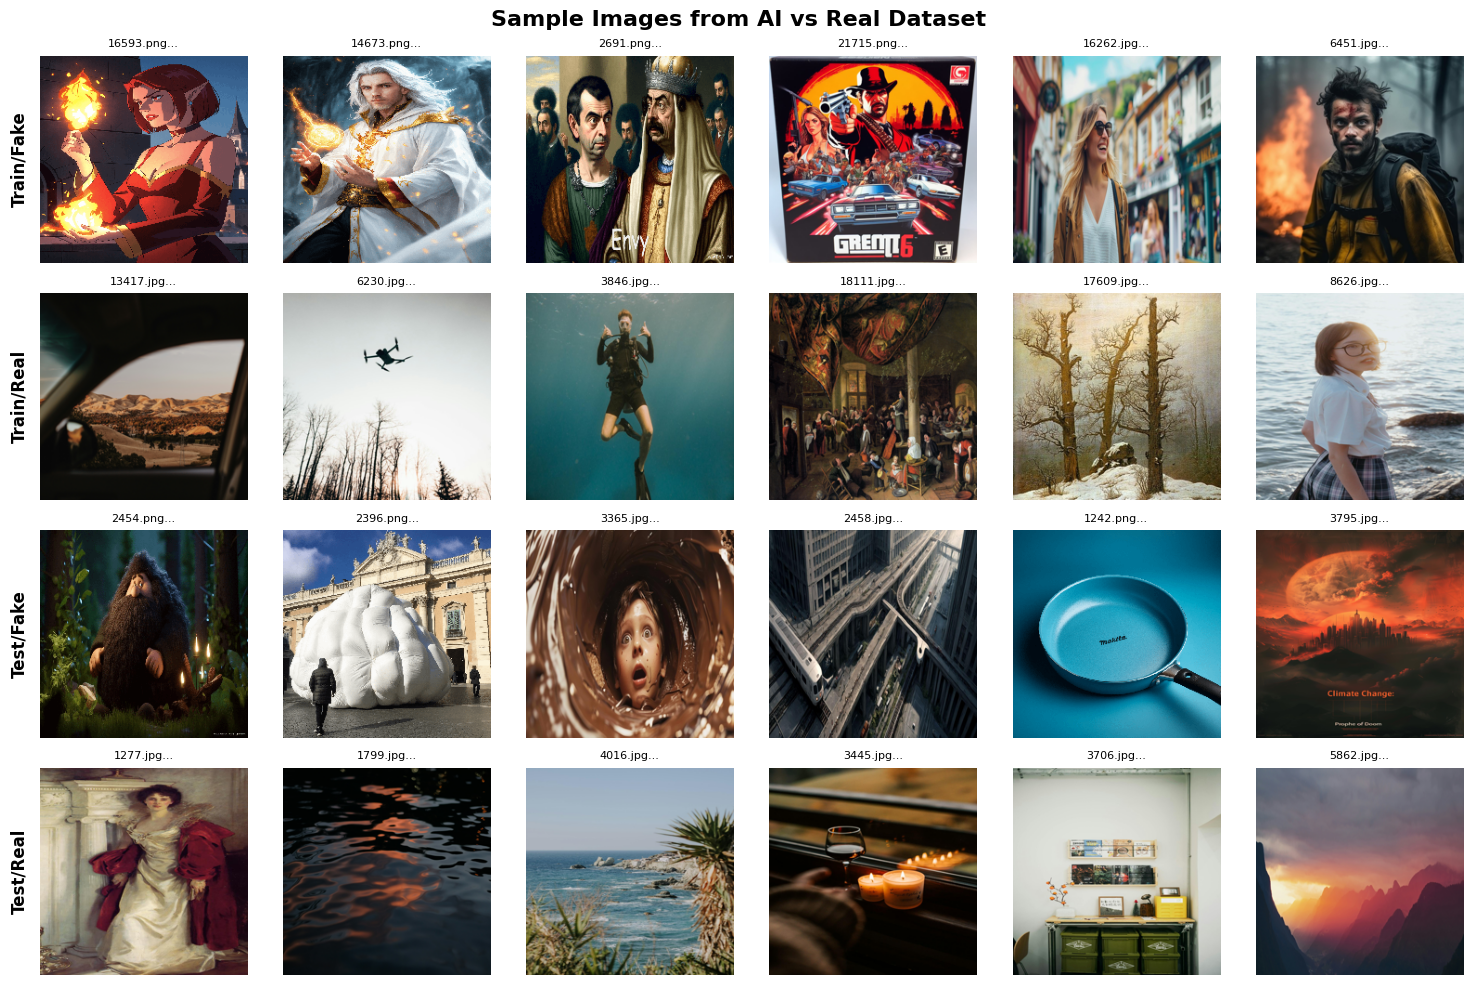


📈 IMAGE PROPERTIES ANALYSIS
------------------------------
  📊 Analyzing train/fake...
  📊 Analyzing train/real...
  📊 Analyzing test/fake...
  📊 Analyzing test/real...
✅ Analyzed 400 images total


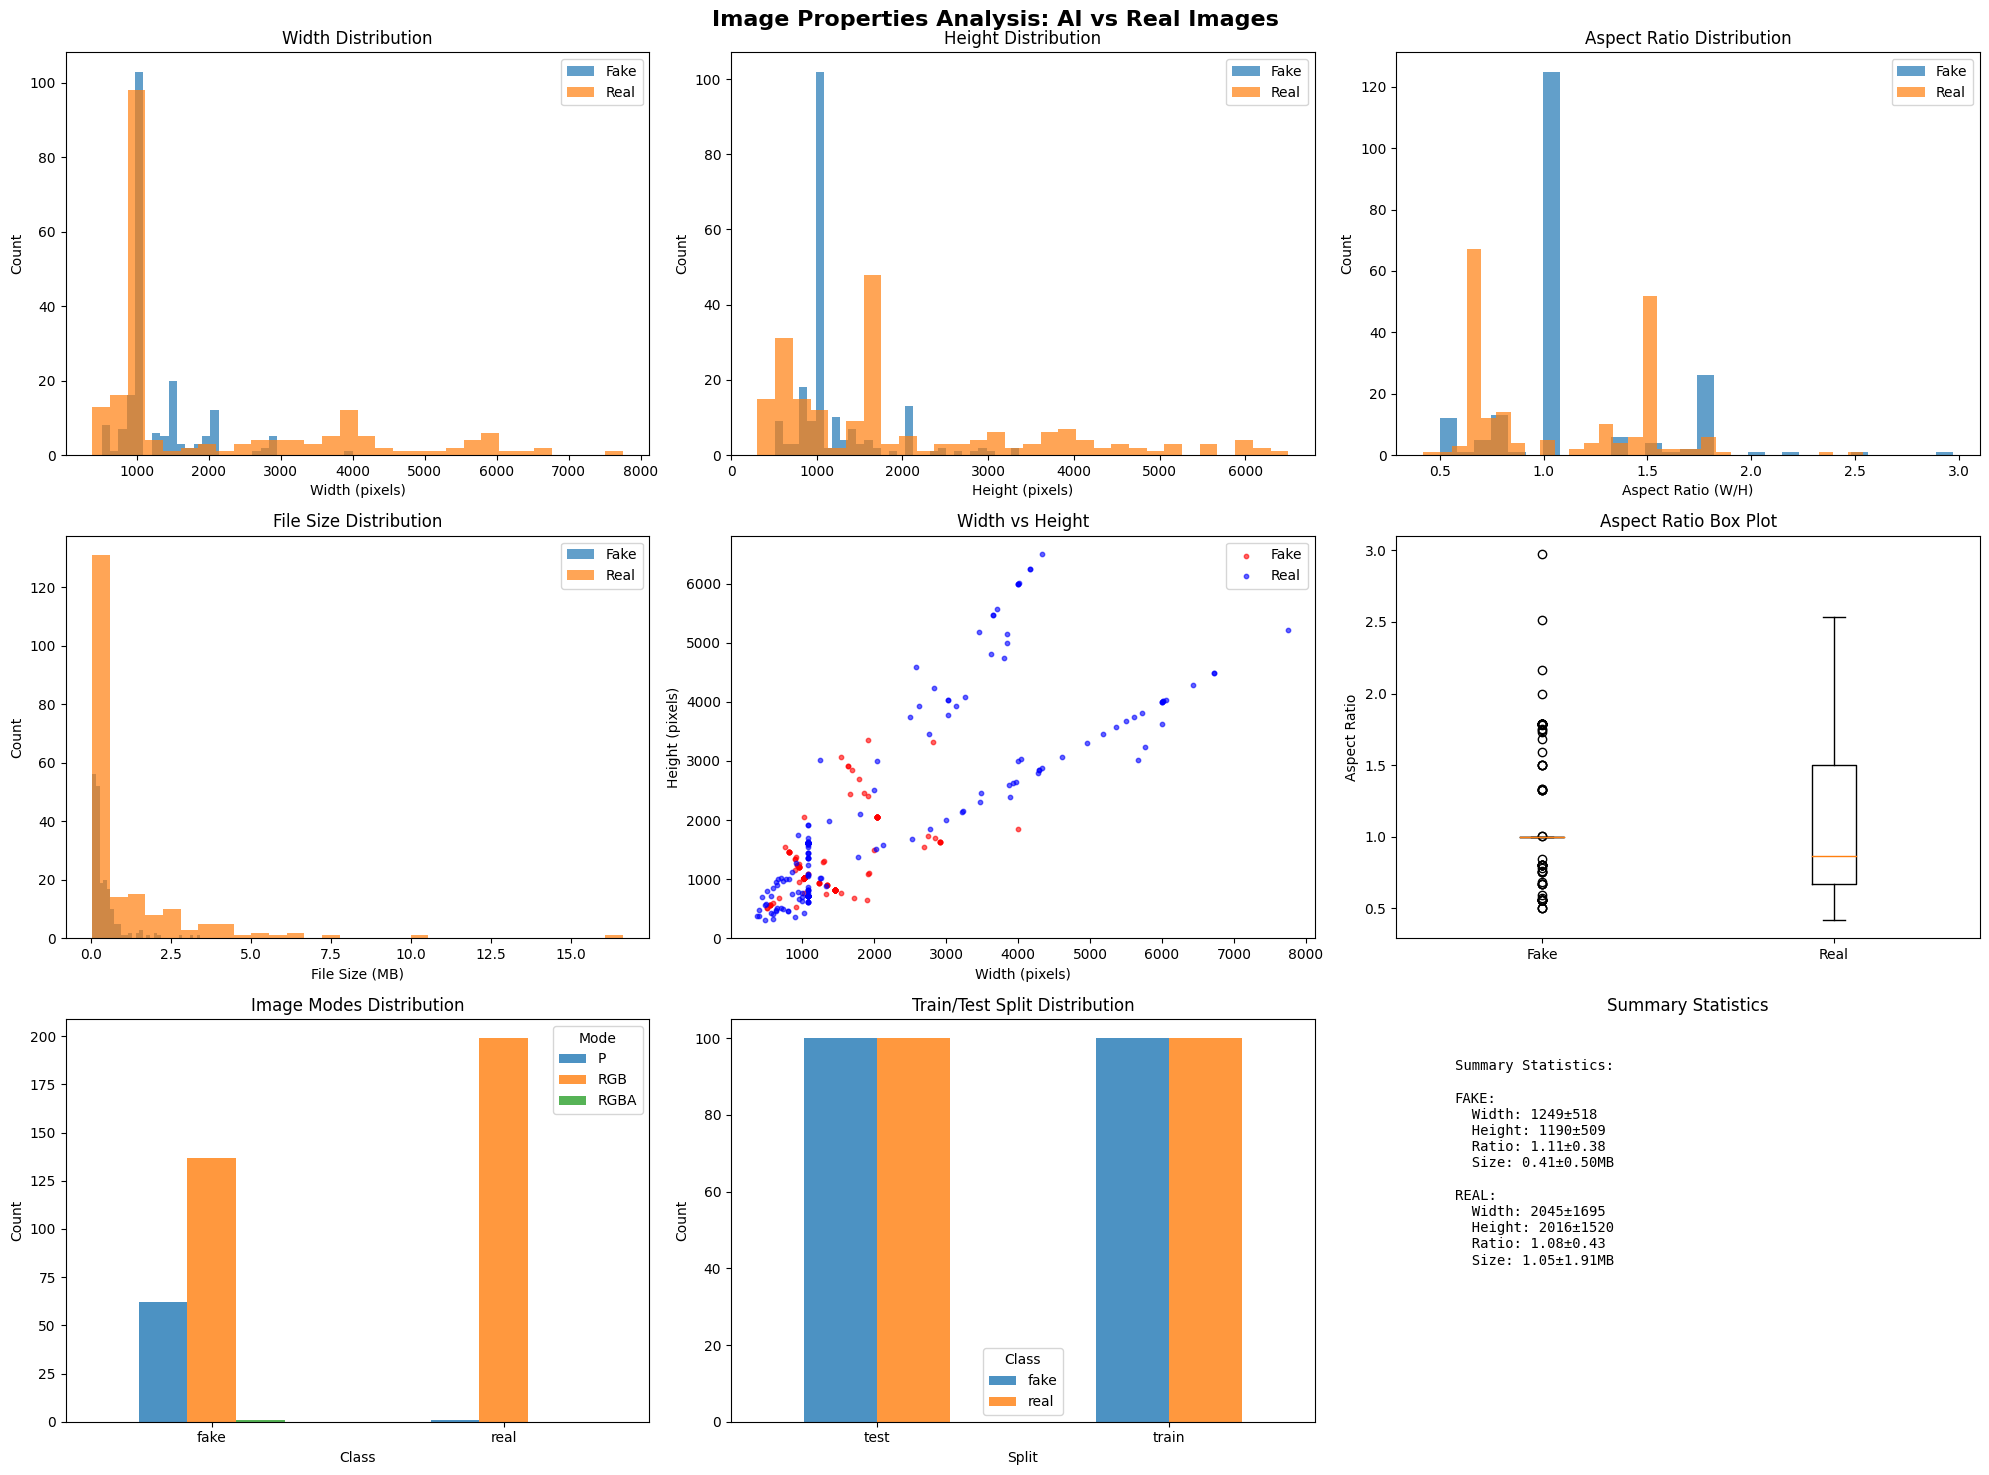


💡 SAMPLING RECOMMENDATIONS
----------------------------------------
📊 Current dataset size:
  • Train: 24,000 fake + 24,000 real = 48,000
  • Test:  6,000 fake + 6,000 real = 12,000

🎯 RECOMMENDED SAMPLE SIZES:

  📝 Quick Test:
     • Train: 200 images (100 per class)
     • Test:  100 images (50 per class)
     • Total: 300 images
     • Uses 0.4% of fake, 0.4% of real

  📝 Small Experiment:
     • Train: 1,000 images (500 per class)
     • Test:  400 images (200 per class)
     • Total: 1,400 images
     • Uses 2.1% of fake, 2.1% of real

  📝 Medium Training:
     • Train: 2,000 images (1,000 per class)
     • Test:  800 images (400 per class)
     • Total: 2,800 images
     • Uses 4.2% of fake, 4.2% of real

  📝 Large Training:
     • Train: 4,000 images (2,000 per class)
     • Test:  1,600 images (800 per class)
     • Total: 5,600 images
     • Uses 8.3% of fake, 8.3% of real

⚡ RECOMMENDED APPROACH:
  1. Start with 'Quick Test' to verify pipeline works
  2. Move to 'Small Exper

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from collections import Counter
import random
import warnings
warnings.filterwarnings('ignore')

class AIImageDatasetEDA:
    """Exploratory Data Analysis for AI vs Real Images Dataset"""
    
    def __init__(self, base_path='/kaggle/input/ai-generated-images-vs-real-images/'):
        """
        Initialize EDA class
        
        Args:
            base_path: Path to the dataset directory containing train/test folders
        """
        self.base_path = base_path
        self.train_path = os.path.join(base_path, 'train')
        self.test_path = os.path.join(base_path, 'test')
        
        # Create output directories
        os.makedirs('eda_plots', exist_ok=True)
        os.makedirs('sample_images', exist_ok=True)
        
        print("🚀 AI vs Real Images Dataset EDA")
        print("=" * 50)
    
    def explore_dataset_structure(self):
        """Analyze the basic structure of the dataset"""
        
        print("📁 DATASET STRUCTURE ANALYSIS")
        print("-" * 30)
        
        # Check if directories exist
        if not os.path.exists(self.train_path):
            print(f"❌ Train directory not found: {self.train_path}")
            return None
            
        if not os.path.exists(self.test_path):
            print(f"❌ Test directory not found: {self.test_path}")
            return None
        
        structure_info = {}
        
        # Analyze train and test splits
        for split in ['train', 'test']:
            split_path = os.path.join(self.base_path, split)
            structure_info[split] = {}
            
            print(f"\n📊 {split.upper()} SET:")
            
            for class_name in ['fake', 'real']:
                class_path = os.path.join(split_path, class_name)
                
                if os.path.exists(class_path):
                    # Count files
                    files = [f for f in os.listdir(class_path) 
                            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff'))]
                    
                    structure_info[split][class_name] = {
                        'count': len(files),
                        'path': class_path,
                        'sample_files': files[:5]  # Store first 5 filenames as samples
                    }
                    
                    print(f"  • {class_name:4s}: {len(files):,} images")
                else:
                    print(f"  • {class_name:4s}: Directory not found")
                    structure_info[split][class_name] = {'count': 0}
        
        # Calculate totals and ratios
        total_train = sum([structure_info['train'][cls]['count'] for cls in ['fake', 'real']])
        total_test = sum([structure_info['test'][cls]['count'] for cls in ['fake', 'real']])
        total_all = total_train + total_test
        
        print(f"\n📈 DATASET SUMMARY:")
        print(f"  • Total images: {total_all:,}")
        print(f"  • Train images: {total_train:,} ({total_train/total_all*100:.1f}%)")
        print(f"  • Test images:  {total_test:,} ({total_test/total_all*100:.1f}%)")
        
        if total_train > 0:
            train_fake_ratio = structure_info['train']['fake']['count'] / total_train
            print(f"  • Train balance: Fake {train_fake_ratio:.1%}, Real {1-train_fake_ratio:.1%}")
        
        if total_test > 0:
            test_fake_ratio = structure_info['test']['fake']['count'] / total_test
            print(f"  • Test balance:  Fake {test_fake_ratio:.1%}, Real {1-test_fake_ratio:.1%}")
        
        return structure_info
    
    def analyze_sample_images(self, n_samples_per_class=20):
        """Analyze sample images from each class"""
        
        print(f"\n🖼️  SAMPLE IMAGE ANALYSIS ({n_samples_per_class} per class)")
        print("-" * 40)
        
        image_stats = {
            'train': {'fake': [], 'real': []},
            'test': {'fake': [], 'real': []}
        }
        
        # Sample and analyze images
        for split in ['train', 'test']:
            for class_name in ['fake', 'real']:
                class_path = os.path.join(self.base_path, split, class_name)
                
                if not os.path.exists(class_path):
                    continue
                
                # Get random sample of images
                all_files = [f for f in os.listdir(class_path) 
                           if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff'))]
                
                sample_files = random.sample(all_files, min(n_samples_per_class, len(all_files)))
                
                # Analyze each sample image
                for img_file in sample_files:
                    img_path = os.path.join(class_path, img_file)
                    
                    try:
                        # Load image
                        img = Image.open(img_path)
                        img_array = np.array(img)
                        
                        # Calculate statistics
                        stats = {
                            'filename': img_file,
                            'width': img.width,
                            'height': img.height,
                            'channels': len(img_array.shape),
                            'mode': img.mode,
                            'size_mb': os.path.getsize(img_path) / (1024*1024),
                            'mean_pixel': np.mean(img_array) if img_array.size > 0 else 0,
                            'std_pixel': np.std(img_array) if img_array.size > 0 else 0
                        }
                        
                        # Fix channels for grayscale
                        if len(img_array.shape) == 2:
                            stats['channels'] = 1
                        elif len(img_array.shape) == 3:
                            stats['channels'] = img_array.shape[2]
                        
                        image_stats[split][class_name].append(stats)
                        
                    except Exception as e:
                        print(f"  ⚠️  Error analyzing {img_file}: {str(e)[:50]}...")
        
        # Print analysis results
        for split in ['train', 'test']:
            print(f"\n📊 {split.upper()} SET IMAGE STATISTICS:")
            
            for class_name in ['fake', 'real']:
                stats_list = image_stats[split][class_name]
                
                if not stats_list:
                    print(f"  • {class_name.capitalize():4s}: No images analyzed")
                    continue
                
                # Calculate averages
                avg_width = np.mean([s['width'] for s in stats_list])
                avg_height = np.mean([s['height'] for s in stats_list])
                avg_size = np.mean([s['size_mb'] for s in stats_list])
                avg_channels = np.mean([s['channels'] for s in stats_list])
                
                # Most common dimensions
                dimensions = [(s['width'], s['height']) for s in stats_list]
                most_common_dim = Counter(dimensions).most_common(1)[0]
                
                # Most common modes
                modes = [s['mode'] for s in stats_list]
                most_common_mode = Counter(modes).most_common(1)[0]
                
                print(f"  • {class_name.capitalize():4s}: {len(stats_list)} samples analyzed")
                print(f"    - Avg dimensions: {avg_width:.0f}×{avg_height:.0f}")
                print(f"    - Most common: {most_common_dim[0]}×{most_common_dim[1]} ({most_common_dim[1]} images)")
                print(f"    - Avg file size: {avg_size:.2f} MB")
                print(f"    - Avg channels: {avg_channels:.1f}")
                print(f"    - Most common mode: {most_common_mode[0]} ({most_common_mode[1]} images)")
        
        return image_stats
    
    def visualize_sample_images(self, n_samples=8):
        """Create a grid visualization of sample images"""
        
        print(f"\n🎨 CREATING SAMPLE VISUALIZATION ({n_samples} images per class)")
        print("-" * 50)
        
        fig, axes = plt.subplots(4, n_samples, figsize=(n_samples*2.5, 10))
        fig.suptitle('Sample Images from AI vs Real Dataset', fontsize=16, fontweight='bold')
        
        row_labels = ['Train/Fake', 'Train/Real', 'Test/Fake', 'Test/Real']
        
        row_idx = 0
        for split in ['train', 'test']:
            for class_name in ['fake', 'real']:
                class_path = os.path.join(self.base_path, split, class_name)
                
                if not os.path.exists(class_path):
                    # Fill row with blank images if path doesn't exist
                    for col_idx in range(n_samples):
                        axes[row_idx, col_idx].axis('off')
                        axes[row_idx, col_idx].text(0.5, 0.5, 'No Images\nFound', 
                                                   ha='center', va='center', transform=axes[row_idx, col_idx].transAxes)
                    row_idx += 1
                    continue
                
                # Get sample images
                all_files = [f for f in os.listdir(class_path) 
                           if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff'))]
                
                sample_files = random.sample(all_files, min(n_samples, len(all_files)))
                
                # Display images
                for col_idx in range(n_samples):
                    if col_idx < len(sample_files):
                        img_path = os.path.join(class_path, sample_files[col_idx])
                        
                        try:
                            img = Image.open(img_path)
                            # Resize for display
                            img = img.resize((224, 224))
                            
                            axes[row_idx, col_idx].imshow(img)
                            axes[row_idx, col_idx].axis('off')
                            axes[row_idx, col_idx].set_title(f'{sample_files[col_idx][:15]}...', fontsize=8)
                            
                        except Exception as e:
                            axes[row_idx, col_idx].axis('off')
                            axes[row_idx, col_idx].text(0.5, 0.5, 'Error\nLoading', 
                                                       ha='center', va='center', transform=axes[row_idx, col_idx].transAxes)
                    else:
                        axes[row_idx, col_idx].axis('off')
                
                # Add row label
                axes[row_idx, 0].text(-0.1, 0.5, row_labels[row_idx], rotation=90, 
                                     ha='center', va='center', transform=axes[row_idx, 0].transAxes, 
                                     fontsize=12, fontweight='bold')
                
                row_idx += 1
        
        plt.tight_layout()
        plt.savefig('eda_plots/sample_images_grid.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def analyze_image_properties(self):
        """Analyze detailed image properties and create distribution plots"""
        
        print(f"\n📈 IMAGE PROPERTIES ANALYSIS")
        print("-" * 30)
        
        # Collect image properties
        properties = {
            'split': [],
            'class': [],
            'width': [],
            'height': [],
            'aspect_ratio': [],
            'file_size_mb': [],
            'channels': [],
            'mode': []
        }
        
        sample_size_per_class = 100  # Analyze 100 images per class for properties
        
        for split in ['train', 'test']:
            for class_name in ['fake', 'real']:
                class_path = os.path.join(self.base_path, split, class_name)
                
                if not os.path.exists(class_path):
                    continue
                
                print(f"  📊 Analyzing {split}/{class_name}...")
                
                # Get sample of images
                all_files = [f for f in os.listdir(class_path) 
                           if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff'))]
                
                sample_files = random.sample(all_files, min(sample_size_per_class, len(all_files)))
                
                for img_file in sample_files:
                    img_path = os.path.join(class_path, img_file)
                    
                    try:
                        img = Image.open(img_path)
                        
                        properties['split'].append(split)
                        properties['class'].append(class_name)
                        properties['width'].append(img.width)
                        properties['height'].append(img.height)
                        properties['aspect_ratio'].append(img.width / img.height)
                        properties['file_size_mb'].append(os.path.getsize(img_path) / (1024*1024))
                        properties['channels'].append(len(np.array(img).shape))
                        properties['mode'].append(img.mode)
                        
                    except Exception as e:
                        continue
        
        # Create DataFrame for analysis
        df = pd.DataFrame(properties)
        
        if len(df) == 0:
            print("❌ No images could be analyzed")
            return None
        
        print(f"✅ Analyzed {len(df)} images total")
        
        # Create comprehensive plots
        fig, axes = plt.subplots(3, 3, figsize=(20, 15))
        fig.suptitle('Image Properties Analysis: AI vs Real Images', fontsize=16, fontweight='bold')
        
        # 1. Width distribution
        for class_name in ['fake', 'real']:
            class_data = df[df['class'] == class_name]['width']
            axes[0,0].hist(class_data, alpha=0.7, label=f'{class_name.capitalize()}', bins=30)
        axes[0,0].set_title('Width Distribution')
        axes[0,0].set_xlabel('Width (pixels)')
        axes[0,0].set_ylabel('Count')
        axes[0,0].legend()
        
        # 2. Height distribution
        for class_name in ['fake', 'real']:
            class_data = df[df['class'] == class_name]['height']
            axes[0,1].hist(class_data, alpha=0.7, label=f'{class_name.capitalize()}', bins=30)
        axes[0,1].set_title('Height Distribution')
        axes[0,1].set_xlabel('Height (pixels)')
        axes[0,1].set_ylabel('Count')
        axes[0,1].legend()
        
        # 3. Aspect ratio distribution
        for class_name in ['fake', 'real']:
            class_data = df[df['class'] == class_name]['aspect_ratio']
            axes[0,2].hist(class_data, alpha=0.7, label=f'{class_name.capitalize()}', bins=30)
        axes[0,2].set_title('Aspect Ratio Distribution')
        axes[0,2].set_xlabel('Aspect Ratio (W/H)')
        axes[0,2].set_ylabel('Count')
        axes[0,2].legend()
        
        # 4. File size distribution
        for class_name in ['fake', 'real']:
            class_data = df[df['class'] == class_name]['file_size_mb']
            axes[1,0].hist(class_data, alpha=0.7, label=f'{class_name.capitalize()}', bins=30)
        axes[1,0].set_title('File Size Distribution')
        axes[1,0].set_xlabel('File Size (MB)')
        axes[1,0].set_ylabel('Count')
        axes[1,0].legend()
        
        # 5. Width vs Height scatter
        colors = {'fake': 'red', 'real': 'blue'}
        for class_name in ['fake', 'real']:
            class_df = df[df['class'] == class_name]
            axes[1,1].scatter(class_df['width'], class_df['height'], 
                            alpha=0.6, c=colors[class_name], label=f'{class_name.capitalize()}', s=10)
        axes[1,1].set_title('Width vs Height')
        axes[1,1].set_xlabel('Width (pixels)')
        axes[1,1].set_ylabel('Height (pixels)')
        axes[1,1].legend()
        
        # 6. Box plot of aspect ratios
        fake_ratios = df[df['class'] == 'fake']['aspect_ratio']
        real_ratios = df[df['class'] == 'real']['aspect_ratio']
        axes[1,2].boxplot([fake_ratios, real_ratios], labels=['Fake', 'Real'])
        axes[1,2].set_title('Aspect Ratio Box Plot')
        axes[1,2].set_ylabel('Aspect Ratio')
        
        # 7. Image modes distribution
        mode_counts = df.groupby(['class', 'mode']).size().unstack(fill_value=0)
        mode_counts.plot(kind='bar', ax=axes[2,0], alpha=0.8)
        axes[2,0].set_title('Image Modes Distribution')
        axes[2,0].set_xlabel('Class')
        axes[2,0].set_ylabel('Count')
        axes[2,0].tick_params(axis='x', rotation=0)
        axes[2,0].legend(title='Mode')
        
        # 8. Split distribution
        split_counts = df.groupby(['split', 'class']).size().unstack(fill_value=0)
        split_counts.plot(kind='bar', ax=axes[2,1], alpha=0.8)
        axes[2,1].set_title('Train/Test Split Distribution')
        axes[2,1].set_xlabel('Split')
        axes[2,1].set_ylabel('Count')
        axes[2,1].tick_params(axis='x', rotation=0)
        axes[2,1].legend(title='Class')
        
        # 9. Summary statistics table
        summary_stats = df.groupby('class')[['width', 'height', 'aspect_ratio', 'file_size_mb']].describe()
        axes[2,2].axis('tight')
        axes[2,2].axis('off')
        
        # Create summary table text
        summary_text = "Summary Statistics:\n\n"
        for class_name in ['fake', 'real']:
            summary_text += f"{class_name.upper()}:\n"
            class_stats = df[df['class'] == class_name]
            summary_text += f"  Width: {class_stats['width'].mean():.0f}±{class_stats['width'].std():.0f}\n"
            summary_text += f"  Height: {class_stats['height'].mean():.0f}±{class_stats['height'].std():.0f}\n"
            summary_text += f"  Ratio: {class_stats['aspect_ratio'].mean():.2f}±{class_stats['aspect_ratio'].std():.2f}\n"
            summary_text += f"  Size: {class_stats['file_size_mb'].mean():.2f}±{class_stats['file_size_mb'].std():.2f}MB\n\n"
        
        axes[2,2].text(0.1, 0.9, summary_text, transform=axes[2,2].transAxes, fontsize=10, 
                      verticalalignment='top', fontfamily='monospace')
        axes[2,2].set_title('Summary Statistics')
        
        plt.tight_layout()
        plt.savefig('eda_plots/image_properties_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        return df
    
    def generate_sampling_recommendation(self, structure_info):
        """Generate recommendations for sampling the large dataset"""
        
        print(f"\n💡 SAMPLING RECOMMENDATIONS")
        print("-" * 40)
        
        total_train_fake = structure_info['train']['fake']['count']
        total_train_real = structure_info['train']['real']['count']
        total_test_fake = structure_info['test']['fake']['count']
        total_test_real = structure_info['test']['real']['count']
        
        print(f"📊 Current dataset size:")
        print(f"  • Train: {total_train_fake:,} fake + {total_train_real:,} real = {total_train_fake + total_train_real:,}")
        print(f"  • Test:  {total_test_fake:,} fake + {total_test_real:,} real = {total_test_fake + total_test_real:,}")
        
        # Recommend different sample sizes
        sample_recommendations = [
            {'name': 'Quick Test', 'train_per_class': 100, 'test_per_class': 50},
            {'name': 'Small Experiment', 'train_per_class': 500, 'test_per_class': 200},
            {'name': 'Medium Training', 'train_per_class': 1000, 'test_per_class': 400},
            {'name': 'Large Training', 'train_per_class': 2000, 'test_per_class': 800}
        ]
        
        print(f"\n🎯 RECOMMENDED SAMPLE SIZES:")
        for rec in sample_recommendations:
            train_total = rec['train_per_class'] * 2
            test_total = rec['test_per_class'] * 2
            total = train_total + test_total
            
            train_pct_fake = (rec['train_per_class'] / total_train_fake) * 100
            train_pct_real = (rec['train_per_class'] / total_train_real) * 100
            
            print(f"\n  📝 {rec['name']}:")
            print(f"     • Train: {train_total:,} images ({rec['train_per_class']:,} per class)")
            print(f"     • Test:  {test_total:,} images ({rec['test_per_class']:,} per class)")
            print(f"     • Total: {total:,} images")
            print(f"     • Uses {train_pct_fake:.1f}% of fake, {train_pct_real:.1f}% of real")
        
        print(f"\n⚡ RECOMMENDED APPROACH:")
        print(f"  1. Start with 'Quick Test' to verify pipeline works")
        print(f"  2. Move to 'Small Experiment' for initial model development")
        print(f"  3. Use 'Medium Training' for serious model training")
        print(f"  4. Scale to 'Large Training' only if needed and resources allow")
        
        return sample_recommendations

def run_comprehensive_eda(dataset_path='/kaggle/input/ai-generated-images-vs-real-images/'):
    """Run complete EDA pipeline"""
    
    # Initialize EDA
    eda = AIImageDatasetEDA(dataset_path)
    
    # 1. Explore dataset structure
    structure_info = eda.explore_dataset_structure()
    
    if structure_info is None:
        print("❌ Cannot proceed - dataset structure issues")
        return None
    
    # 2. Analyze sample images
    image_stats = eda.analyze_sample_images(n_samples_per_class=25)
    
    # 3. Visualize samples
    eda.visualize_sample_images(n_samples=6)
    
    # 4. Analyze image properties
    properties_df = eda.analyze_image_properties()
    
    # 5. Generate sampling recommendations
    recommendations = eda.generate_sampling_recommendation(structure_info)
    
    print(f"\n🎉 EDA COMPLETE!")
    print(f"Check the 'eda_plots' folder for saved visualizations.")
    
    return {
        'structure_info': structure_info,
        'image_stats': image_stats,
        'properties_df': properties_df,
        'recommendations': recommendations
    }

# Run the EDA
if __name__ == "__main__":
    eda_results = run_comprehensive_eda()

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB0, VGG16
from tensorflow.keras.preprocessing.image import img_to_array, ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
import pickle
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

class AIImageCNNBiLSTMClassifier:
    """Complete CNN + BiLSTM model for AI vs Real Image Classification"""
    
    def __init__(self, dataset_path='/kaggle/input', cnn_backbone='efficientnetb0', 
                 sequence_length=8, img_size=224):
        self.dataset_path = dataset_path
        self.cnn_backbone = cnn_backbone.lower()
        self.sequence_length = sequence_length
        self.img_size = img_size
        self.model = None
        self.cnn_model = None
        self.history = None
        
        # Create output directories
        os.makedirs('models', exist_ok=True)
        os.makedirs('features', exist_ok=True)
        os.makedirs('plots', exist_ok=True)
        
        print(f"AI Image CNN+BiLSTM Classifier")
        print(f"CNN Backbone: {cnn_backbone}")
        print(f"Sequence Length: {sequence_length}")
        print(f"Image Size: {img_size}x{img_size}")
        print("=" * 50)
    
    def load_cnn_backbone(self):
        """Load and prepare CNN backbone for feature extraction"""
        
        print(f"Loading {self.cnn_backbone} backbone...")
        
        if self.cnn_backbone == 'efficientnetb0':
            base_model = EfficientNetB0(weights='imagenet', include_top=False, 
                                      input_shape=(self.img_size, self.img_size, 3))
            feature_dim = 1280
        elif self.cnn_backbone == 'vgg16':
            base_model = VGG16(weights='imagenet', include_top=False,
                              input_shape=(self.img_size, self.img_size, 3))
            feature_dim = 512
        else:
            raise ValueError(f"Unsupported backbone: {self.cnn_backbone}")
        
        # Add global average pooling
        x = base_model.output
        x = layers.GlobalAveragePooling2D()(x)
        
        self.cnn_model = models.Model(base_model.input, x)
        self.feature_dim = feature_dim
        
        print(f"CNN backbone loaded. Feature dimension: {feature_dim}")
        return self.cnn_model
    
    def create_image_patches(self, image, n_patches=8):
        """Create patches from image for sequence processing"""
        patches = []
        
        if n_patches == 8:
            # Mix of patches and augmented versions
            h, w = image.shape[:2]
            
            # 4 corner patches
            h_third, w_third = h//3, w//3
            patches = [
                image[0:h_third*2, 0:w_third*2],        # Top-left region
                image[0:h_third*2, w_third:w],          # Top-right region  
                image[h_third:h, 0:w_third*2],          # Bottom-left region
                image[h_third:h, w_third:w],            # Bottom-right region
            ]
            
            # 4 augmented versions of center crop
            center_crop = image[h//4:3*h//4, w//4:3*w//4]
            
            # Add different augmentations
            patches.extend([
                center_crop,                                    # Original center
                cv2.flip(center_crop, 1),                      # Horizontal flip
                cv2.flip(center_crop, 0),                      # Vertical flip
                np.rot90(center_crop, k=1)                     # 90-degree rotation
            ])
        
        # Resize all patches to target size
        resized_patches = []
        for patch in patches:
            if len(patch.shape) == 3:
                resized_patch = cv2.resize(patch, (self.img_size, self.img_size))
            else:
                resized_patch = cv2.resize(patch, (self.img_size, self.img_size))
            resized_patches.append(resized_patch)
        
        return np.array(resized_patches)
    
    def load_sampled_data(self, train_per_class=2000, test_per_class=800, random_state=42):
        """Load sampled data from the dataset"""
        
        print(f"Loading sampled data: {train_per_class} train, {test_per_class} test per class...")
        
        # Set random seed
        random.seed(random_state)
        np.random.seed(random_state)
        
        X_train, y_train = [], []
        X_test, y_test = [], []
        
        # Load training data
        for class_idx, class_name in enumerate(['fake', 'real']):
            train_path = os.path.join(self.dataset_path, 'train', class_name)
            
            # Get all image files
            image_files = [f for f in os.listdir(train_path) 
                          if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
            
            # Sample random files
            sampled_files = random.sample(image_files, min(train_per_class, len(image_files)))
            
            print(f"  Loading {len(sampled_files)} train/{class_name} images...")
            
            for i, img_file in enumerate(sampled_files):
                if (i + 1) % 200 == 0:
                    print(f"    Processed {i + 1}/{len(sampled_files)} images")
                    
                img_path = os.path.join(train_path, img_file)
                
                try:
                    # Load and process image
                    img = cv2.imread(img_path)
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, (self.img_size, self.img_size))
                    
                    # Create patches/sequence
                    patches = self.create_image_patches(img, self.sequence_length)
                    
                    X_train.append(patches)
                    y_train.append(class_idx)
                    
                except Exception as e:
                    print(f"    Error loading {img_file}: {str(e)[:50]}...")
                    continue
        
        # Load test data
        for class_idx, class_name in enumerate(['fake', 'real']):
            test_path = os.path.join(self.dataset_path, 'test', class_name)
            
            image_files = [f for f in os.listdir(test_path) 
                          if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
            
            sampled_files = random.sample(image_files, min(test_per_class, len(image_files)))
            
            print(f"  Loading {len(sampled_files)} test/{class_name} images...")
            
            for i, img_file in enumerate(sampled_files):
                if (i + 1) % 100 == 0:
                    print(f"    Processed {i + 1}/{len(sampled_files)} images")
                    
                img_path = os.path.join(test_path, img_file)
                
                try:
                    img = cv2.imread(img_path)
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, (self.img_size, self.img_size))
                    
                    patches = self.create_image_patches(img, self.sequence_length)
                    
                    X_test.append(patches)
                    y_test.append(class_idx)
                    
                except Exception as e:
                    continue
        
        X_train = np.array(X_train)
        y_train = np.array(y_train)
        X_test = np.array(X_test)
        y_test = np.array(y_test)
        
        print(f"Data loaded successfully:")
        print(f"  Train: {X_train.shape}, Test: {X_test.shape}")
        print(f"  Train labels: fake={np.sum(y_train==0)}, real={np.sum(y_train==1)}")
        print(f"  Test labels:  fake={np.sum(y_test==0)}, real={np.sum(y_test==1)}")
        
        return X_train, y_train, X_test, y_test
    
    def extract_features(self, X):
        """Extract CNN features from image patches"""
        
        print("Extracting CNN features...")
        
        if self.cnn_model is None:
            self.load_cnn_backbone()
        
        # Reshape for batch processing
        n_samples, seq_len, h, w, c = X.shape
        X_reshaped = X.reshape(-1, h, w, c)
        
        # Preprocess for the specific CNN
        if self.cnn_backbone == 'efficientnetb0':
            X_preprocessed = tf.keras.applications.efficientnet.preprocess_input(X_reshaped)
        elif self.cnn_backbone == 'vgg16':
            X_preprocessed = tf.keras.applications.vgg16.preprocess_input(X_reshaped)
        
        # Extract features in batches to avoid memory issues
        batch_size = 64
        features_list = []
        
        for i in range(0, len(X_preprocessed), batch_size):
            batch = X_preprocessed[i:i+batch_size]
            batch_features = self.cnn_model.predict(batch, verbose=0)
            features_list.append(batch_features)
            
            if (i // batch_size + 1) % 10 == 0:
                print(f"  Processed {i + len(batch)}/{len(X_preprocessed)} patches")
        
        features = np.concatenate(features_list, axis=0)
        
        # Reshape back to sequences
        features = features.reshape(n_samples, seq_len, -1)
        
        print(f"Features extracted: {features.shape}")
        return features
    
    def build_cnn_bilstm_model(self, input_shape):
        """Build CNN + BiLSTM model"""
        
        print(f"Building CNN+BiLSTM model with input shape: {input_shape}")
        
        inputs = layers.Input(shape=input_shape)
        
        # Multi-scale 1D convolutions for feature refinement
        conv1 = layers.Conv1D(128, 3, activation='relu', padding='same')(inputs)
        conv1 = layers.BatchNormalization()(conv1)
        conv1 = layers.Dropout(0.2)(conv1)
        
        conv2 = layers.Conv1D(128, 5, activation='relu', padding='same')(inputs)
        conv2 = layers.BatchNormalization()(conv2)
        conv2 = layers.Dropout(0.2)(conv2)
        
        # Concatenate multi-scale features
        conv_concat = layers.concatenate([conv1, conv2])
        
        # Bidirectional LSTM layers
        lstm1 = layers.Bidirectional(
            layers.LSTM(256, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)
        )(conv_concat)
        lstm1 = layers.LayerNormalization()(lstm1)
        
        lstm2 = layers.Bidirectional(
            layers.LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)
        )(lstm1)
        lstm2 = layers.LayerNormalization()(lstm2)
        
        # Attention mechanism
        attention_weights = layers.Dense(1, activation='tanh')(lstm2)
        attention_weights = layers.Flatten()(attention_weights)
        attention_weights = layers.Activation('softmax')(attention_weights)
        attention_weights = layers.RepeatVector(256)(attention_weights)
        attention_weights = layers.Permute([2, 1])(attention_weights)
        
        # Apply attention
        attended_features = layers.Multiply()([lstm2, attention_weights])
        attended_features = layers.Lambda(
            lambda x: tf.reduce_sum(x, axis=1),
            output_shape=(256,)
        )(attended_features)
        
        # Global pooling features
        global_max = layers.GlobalMaxPooling1D()(lstm2)
        global_avg = layers.GlobalAveragePooling1D()(lstm2)
        
        # Combine features
        combined = layers.concatenate([attended_features, global_max, global_avg])
        
        # Classification head
        dense1 = layers.Dense(512, activation='relu', kernel_regularizer=l2(0.001))(combined)
        dense1 = layers.BatchNormalization()(dense1)
        dropout1 = layers.Dropout(0.5)(dense1)
        
        dense2 = layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001))(dropout1)
        dense2 = layers.BatchNormalization()(dense2)
        dropout2 = layers.Dropout(0.4)(dropout2)
        
        dense3 = layers.Dense(128, activation='relu')(dropout2)
        dropout3 = layers.Dropout(0.3)(dense3)
        
        outputs = layers.Dense(1, activation='sigmoid')(dropout3)
        
        model = models.Model(inputs, outputs)
        
        # Compile with class weights
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy', 'precision', 'recall']
        )
        
        return model
    
    def train_large_model(self, epochs=50, use_cached_features=True):
        """Train the CNN+BiLSTM model with large dataset"""
        
        # Large training configuration
        train_per_class = 2000
        test_per_class = 800
        
        print(f"LARGE TRAINING CONFIGURATION")
        print(f"Train: {train_per_class*2} images ({train_per_class} per class)")
        print(f"Test:  {test_per_class*2} images ({test_per_class} per class)")
        print(f"Total: {(train_per_class + test_per_class)*2} images")
        print("=" * 50)
        
        # Load data
        X_train, y_train, X_test, y_test = self.load_sampled_data(train_per_class, test_per_class)
        
        # Extract or load features
        features_train_path = f'features/train_features_large_{train_per_class}.npy'
        features_test_path = f'features/test_features_large_{test_per_class}.npy'
        labels_train_path = f'features/train_labels_large_{train_per_class}.npy'
        labels_test_path = f'features/test_labels_large_{test_per_class}.npy'
        
        if use_cached_features and all(os.path.exists(p) for p in [features_train_path, features_test_path, labels_train_path, labels_test_path]):
            print("Loading cached features...")
            X_train_features = np.load(features_train_path)
            X_test_features = np.load(features_test_path)
            y_train = np.load(labels_train_path)
            y_test = np.load(labels_test_path)
        else:
            print("Extracting new features...")
            X_train_features = self.extract_features(X_train)
            X_test_features = self.extract_features(X_test)
            
            # Cache features and labels
            np.save(features_train_path, X_train_features)
            np.save(features_test_path, X_test_features)
            np.save(labels_train_path, y_train)
            np.save(labels_test_path, y_test)
            print("Features and labels cached for future use")
        
        # Build model
        input_shape = (X_train_features.shape[1], X_train_features.shape[2])
        self.model = self.build_cnn_bilstm_model(input_shape)
        
        print("\nModel Summary:")
        self.model.summary()
        
        # Calculate class weights
        class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}
        print(f"Class weights: {class_weight_dict}")
        
        # Callbacks
        callbacks_list = [
            callbacks.EarlyStopping(
                monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7, verbose=1
            ),
            callbacks.ModelCheckpoint(
                'models/best_cnn_bilstm_large_model.h5',
                monitor='val_accuracy', save_best_only=True, verbose=1
            ),
            callbacks.CSVLogger('models/training_history_large.csv')
        ]
        
        # Train model
        print(f"\nTraining model for {epochs} epochs...")
        
        self.history = self.model.fit(
            X_train_features, y_train,
            validation_data=(X_test_features, y_test),
            epochs=epochs,
            batch_size=16,
            class_weight=class_weight_dict,
            callbacks=callbacks_list,
            verbose=1
        )
        
        # Final evaluation
        print("\nFinal Model Evaluation:")
        test_loss, test_acc, test_prec, test_rec = self.model.evaluate(X_test_features, y_test, verbose=0)
        print(f"Test Accuracy: {test_acc:.4f}")
        print(f"Test Precision: {test_prec:.4f}")
        print(f"Test Recall: {test_rec:.4f}")
        
        # Create comprehensive evaluation
        self.evaluate_and_plot_results(X_test_features, y_test)
        
        return self.history
    
    def evaluate_and_plot_results(self, X_test_features, y_test):
        """Comprehensive evaluation with plots"""
        
        print("Creating comprehensive evaluation plots...")
        
        # Predictions
        y_pred_proba = self.model.predict(X_test_features)
        y_pred = (y_pred_proba > 0.5).astype(int).flatten()
        
        # Metrics
        from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
        
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        print(f"\nDetailed Evaluation Results:")
        print(f"Accuracy:  {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall:    {recall:.4f}")
        print(f"F1-Score:  {f1:.4f}")
        
        # Create comprehensive plots
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('CNN+BiLSTM Large Training Results', fontsize=16, fontweight='bold')
        
        # 1. Training History - Accuracy
        if self.history:
            axes[0,0].plot(self.history.history['accuracy'], label='Train Accuracy', linewidth=2)
            axes[0,0].plot(self.history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
            axes[0,0].set_title('Training History - Accuracy')
            axes[0,0].set_xlabel('Epoch')
            axes[0,0].set_ylabel('Accuracy')
            axes[0,0].legend()
            axes[0,0].grid(True, alpha=0.3)
        
        # 2. Training History - Loss
        if self.history:
            axes[0,1].plot(self.history.history['loss'], label='Train Loss', linewidth=2)
            axes[0,1].plot(self.history.history['val_loss'], label='Val Loss', linewidth=2)
            axes[0,1].set_title('Training History - Loss')
            axes[0,1].set_xlabel('Epoch')
            axes[0,1].set_ylabel('Loss')
            axes[0,1].legend()
            axes[0,1].grid(True, alpha=0.3)
        
        # 3. Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,2],
                   xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
        axes[0,2].set_title('Confusion Matrix')
        axes[0,2].set_ylabel('True Label')
        axes[0,2].set_xlabel('Predicted Label')
        
        # 4. ROC Curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        axes[1,0].plot(fpr, tpr, color='darkorange', lw=3, 
                      label=f'ROC Curve (AUC = {roc_auc:.3f})')
        axes[1,0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[1,0].set_xlabel('False Positive Rate')
        axes[1,0].set_ylabel('True Positive Rate')
        axes[1,0].set_title('ROC Curve')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)
        
        # 5. Prediction Distribution
        fake_probs = y_pred_proba[y_test == 0]
        real_probs = y_pred_proba[y_test == 1]
        
        axes[1,1].hist(fake_probs, bins=30, alpha=0.7, label='Fake (True)', color='red', density=True)
        axes[1,1].hist(real_probs, bins=30, alpha=0.7, label='Real (True)', color='blue', density=True)
        axes[1,1].axvline(x=0.5, color='black', linestyle='--', label='Threshold', linewidth=2)
        axes[1,1].set_xlabel('Prediction Probability')
        axes[1,1].set_ylabel('Density')
        axes[1,1].set_title('Prediction Distribution')
        axes[1,1].legend()
        
        # 6. Metrics Bar Chart
        metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']
        values = [accuracy, precision, recall, f1, roc_auc]
        
        colors = ['green' if v >= 0.8 else 'orange' if v >= 0.6 else 'red' for v in values]
        bars = axes[1,2].bar(metrics, values, color=colors, alpha=0.8)
        axes[1,2].set_ylim(0, 1)
        axes[1,2].set_ylabel('Score')
        axes[1,2].set_title('Performance Metrics')
        axes[1,2].tick_params(axis='x', rotation=45)
        
        # Add value labels
        for bar, value in zip(bars, values):
            axes[1,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                          f'{value:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('plots/cnn_bilstm_large_training_results.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Classification Report
        print(f"\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))
        
        # Sample predictions
        print(f"\nSample Predictions (first 20 test images):")
        print("-" * 60)
        correct_count = 0
        
        for i in range(min(20, len(y_test))):
            true_label = 'Fake' if y_test[i] == 0 else 'Real'
            pred_label = 'Fake' if y_pred[i] == 0 else 'Real'
            confidence = y_pred_proba[i][0] if y_pred[i] == 1 else 1 - y_pred_proba[i][0]
            
            is_correct = y_test[i] == y_pred[i]
            if is_correct:
                correct_count += 1
                
            status = "✓" if is_correct else "✗"
            print(f"{status} Sample {i+1:2d}: True={true_label:4s} | Pred={pred_label:4s} | Conf={confidence:.3f}")
        
        print(f"\nSample Accuracy: {correct_count}/20 = {correct_count/20:.1%}")
        
        return {
            'accuracy': accuracy,
            'precision': precision, 
            'recall': recall,
            'f1_score': f1,
            'roc_auc': roc_auc,
            'confusion_matrix': cm
        }

# Main execution function
def run_large_training():
    """Run the complete large training pipeline"""
    
    print("=" * 70)
    print("STARTING LARGE TRAINING FOR AI vs REAL IMAGE CLASSIFICATION")
    print("=" * 70)
    
    # Initialize classifier
    classifier = AIImageCNNBiLSTMClassifier(
        dataset_path='/kaggle/input/ai-generated-images-vs-real-images/',
        cnn_backbone='efficientnetb0',
        sequence_length=8,
        img_size=224
    )
    
    # Train the model
    history = classifier.train_large_model(
        epochs=50,
        use_cached_features=True
    )
    
    print("\n" + "=" * 70)
    print("TRAINING COMPLETED!")
    print("=" * 70)
    print("Files saved:")
    print("- models/best_cnn_bilstm_large_model.h5 (best model)")
    print("- models/training_history_large.csv (training logs)")
    print("- plots/cnn_bilstm_large_training_results.png (evaluation plots)")
    print("- features/ (cached CNN features)")
    
    return classifier, history

# Execute the training

classifier, history = run_large_training()

2025-09-17 09:28:42.068410: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758101322.312576      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758101322.383610      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


STARTING LARGE TRAINING FOR AI vs REAL IMAGE CLASSIFICATION
AI Image CNN+BiLSTM Classifier
CNN Backbone: efficientnetb0
Sequence Length: 8
Image Size: 224x224
LARGE TRAINING CONFIGURATION
Train: 4000 images (2000 per class)
Test:  1600 images (800 per class)
Total: 5600 images
Loading sampled data: 2000 train, 800 test per class...
  Loading 2000 train/fake images...


Corrupt JPEG data: 164387 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


    Processed 200/2000 images


Corrupt JPEG data: premature end of data segment


...

I0000 00:00:1758101806.318676      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
CNN backbone loaded. Feature dimension: 1280


I0000 00:00:1758101813.984619      99 service.cc:148] XLA service 0x792c64002ff0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758101813.985660      99 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1758101814.758280      99 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1758101819.824780      99 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  Processed 640/32000 patches
  Processed 1280/32000 patches
  Processed 1920/32000 patches
  Processed 2560/32000 patches
  Processed 3200/32000 patches
  Processed 3840/32000 patches
  Processed 4480/32000 patches
  Processed 5120/32000 patches
  Processed 5760/32000 patches
  Processed 6400/32000 patches
  Processed 7040/32000 patches
  Processed 7680/32000 patches
  Processed 8320/32000 patches
  Processed 8960/32000 patches
  Processed 9600/32000 patches
  Processed 10240/32000 patches
  Processed 10880/32000 patches
  Processed 11520/32000 patches
  Processed 12160/32000 patches
  Processed 12800/32000 patches
  Processed 13440/32000 patches
  Processed 14080/32000 patches
  Processed 14720/32000 patches
  Processed 15360/32000 patches
  Processed 16000/32000 patches
  Processed 16640/32000 patches
  Processed 17280/32000 patches
  Processed 17920/32000 patches
  Processed 18560/32000 patches
  Processed 19200/32000 patches
  Processed 19840/32000 patches
  Processed 20480/32000 

UnboundLocalError: cannot access local variable 'dropout2' where it is not associated with a value

BiLSTM+ViT Trainer for Pre-extracted CNN Features
TRAINING BiLSTM+ViT MODEL ON PRE-EXTRACTED CNN FEATURES
Loading pre-extracted CNN features...
Found cached CNN features at: features/train_features_large_2000.npy
Loaded CNN features successfully:
  X_train: (4000, 8, 1280)
  X_test:  (1600, 8, 1280)
  y_train: (4000,) (fake=2000, real=2000)
  y_test:  (1600,) (fake=800, real=800)
Building BiLSTM+ViT model for CNN features with input shape: (8, 1280)
Input: Pre-extracted CNN features
Building BiLSTM branch...
Building ViT branch...
Building advanced fusion layer...
Combined features dimension: (None, 5376)
Building enhanced classification head...

BiLSTM+ViT Model Summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 8, 1280)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 8, 512)    │    655,872 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 8, 512)    │      4,096 │ dense_9[0][0]     │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 8, 512)    │  1,050,624 │ positional_encod… │
│ (MultiHeadAttentio… │                   │            │ positional_encod… │
│                     │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 8, 512)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 8, 512)    │          0 │ positional_encod… │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 512)    │      1,024 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 8, 1024)   │    525,312 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 8, 1024)   │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 8, 512)    │    524,800 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 8, 512)    │          0 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 8, 512)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 512)    │      1,024 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 8, 512)    │  1,050,624 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 8, 512)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 8, 512)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 512)    │      1,024 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 8, 1024)   │    525,312 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 8, 1024)   │          0 │ dense_12[0][0]  

 Total params: 26,768,131 (102.11 MB)

 Trainable params: 26,764,547 (102.10 MB)

 Non-trainable params: 3,584 (14.00 KB)


Class weights: {0: 1.0, 1: 1.0}

Starting BiLSTM+ViT training for 60 epochs...
Epoch 1/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.6946 - loss: 3.1698 - precision: 0.6934 - recall: 0.7346
Epoch 1: val_accuracy improved from -inf to 0.53688, saving model to models/best_bilstm_vit_model.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 90s 144ms/step - accuracy: 0.6948 - loss: 3.1689 - precision: 0.6935 - recall: 0.7347 - val_accuracy: 0.5369 - val_loss: 3.1729 - val_precision: 0.5192 - val_recall: 0.9987 - learning_rate: 0.0010
Epoch 2/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.8191 - loss: 2.2417 - precision: 0.8265 - recall: 0.8167
Epoch 2: val_accuracy improved from 0.53688 to 0.83250, saving model to models/best_bilstm_vit_model.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 31s 124ms/step - accuracy: 0.8191 - loss: 2.2409 - precision: 0.8264 - recall: 0.8167 - val_accuracy: 0.8325 - val_loss: 1.6704 - val_precision: 0.7917 - val_recall: 0.9025 - learning_rate: 0.0010
Epoch 3/60
250/

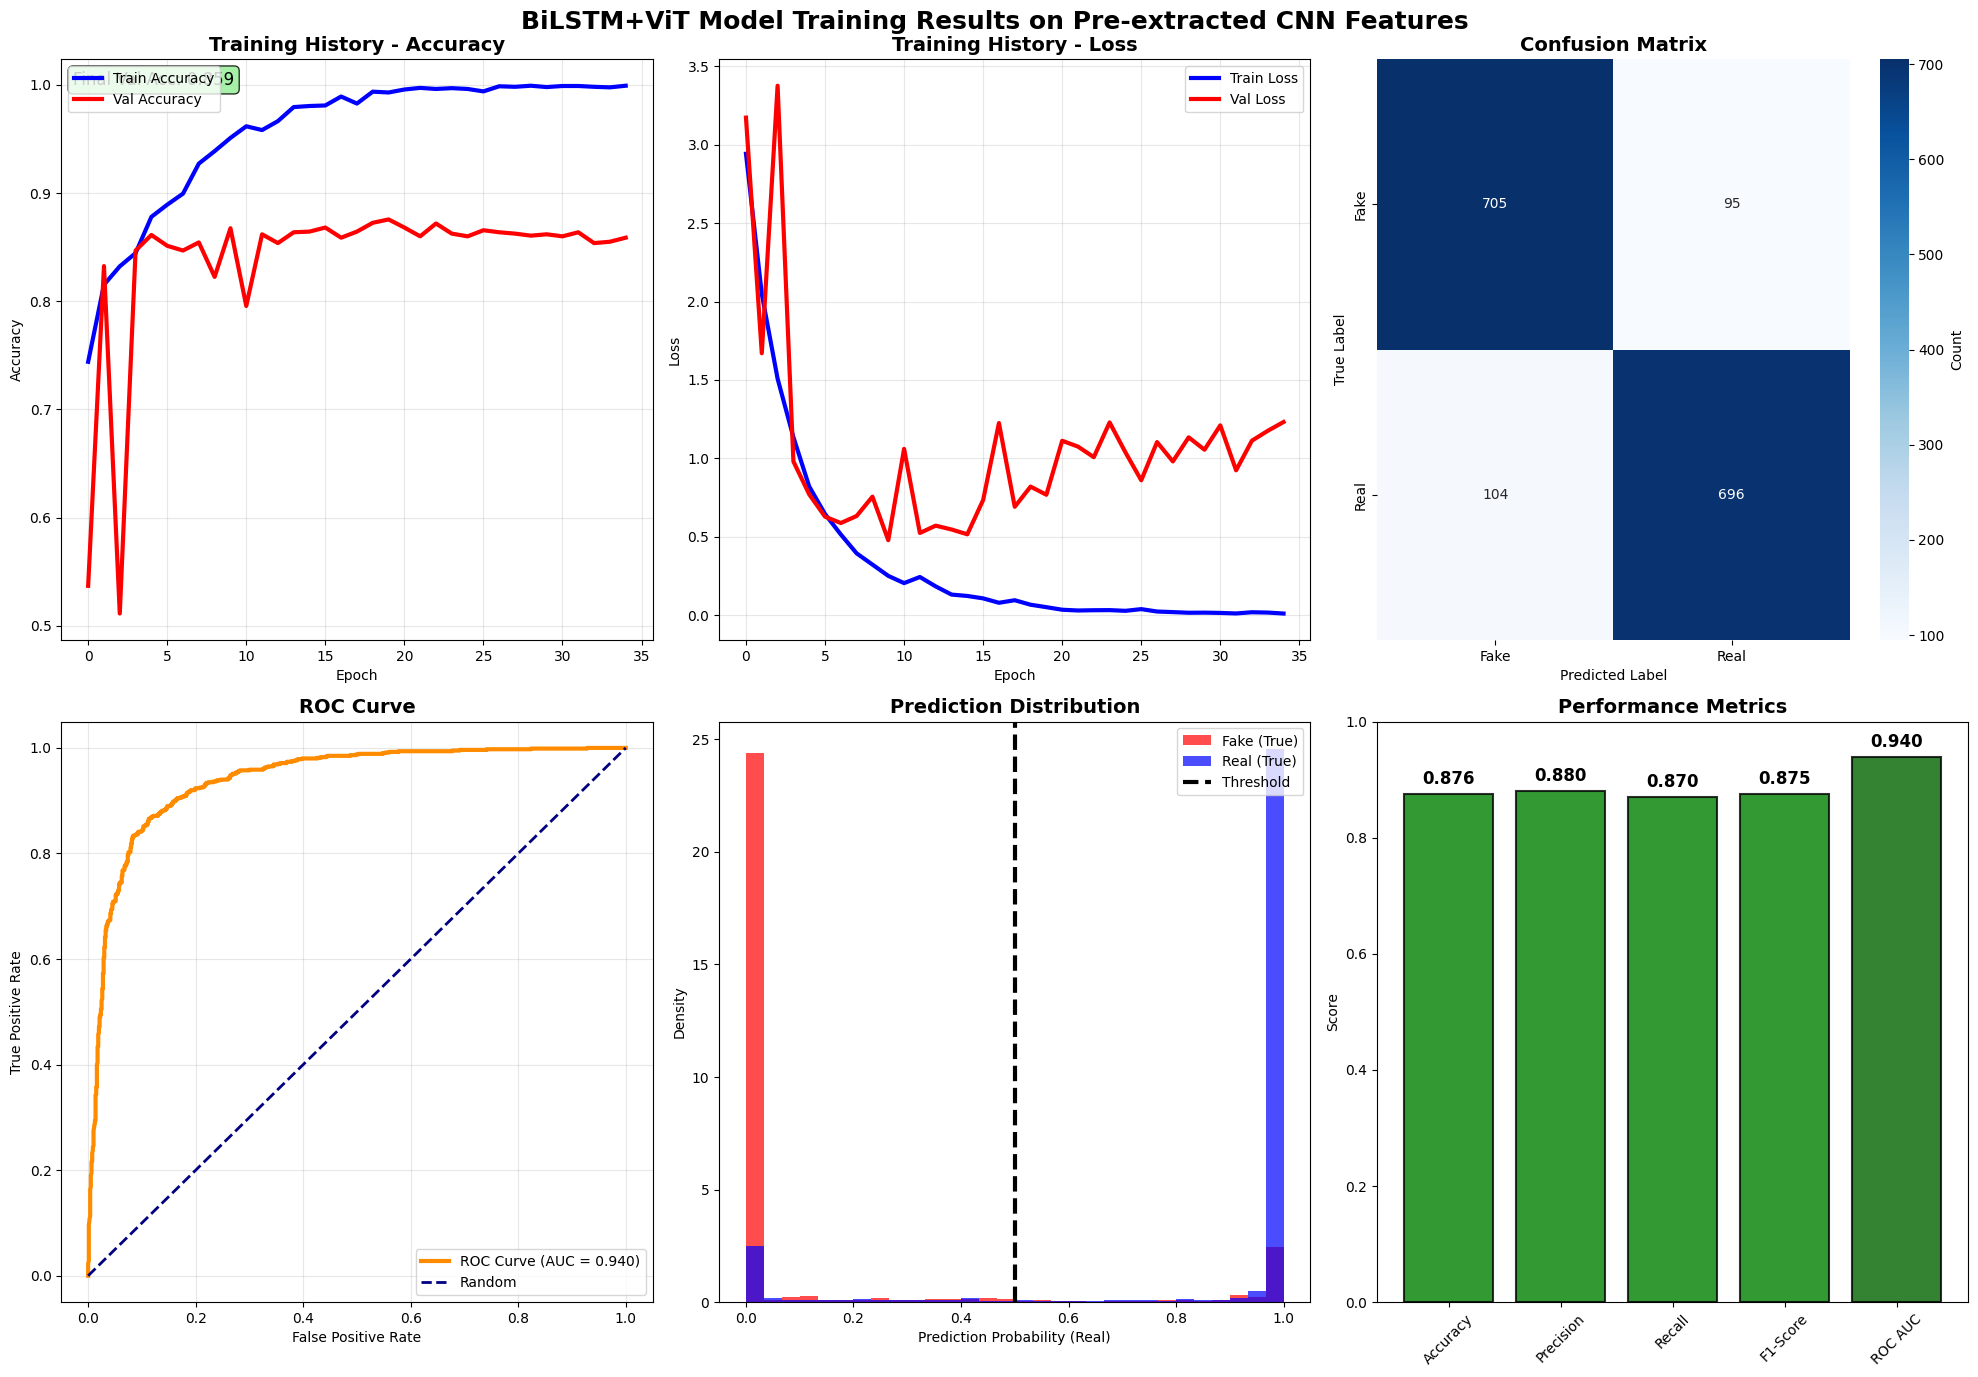


Detailed Classification Report:
              precision    recall  f1-score   support

        Fake       0.87      0.88      0.88       800
        Real       0.88      0.87      0.87       800

    accuracy                           0.88      1600
   macro avg       0.88      0.88      0.88      1600
weighted avg       0.88      0.88      0.88      1600


Sample Predictions Analysis (first 25 test samples):
 #   True   Pred   Conf   Status
-----------------------------------------------------------------
 1   Fake   Fake  0.999 ✓ CORRECT
 2   Fake   Real  1.000  ✗ WRONG
 3   Fake   Fake  1.000 ✓ CORRECT
 4   Fake   Fake  1.000 ✓ CORRECT
 5   Fake   Fake  1.000 ✓ CORRECT
 6   Fake   Fake  1.000 ✓ CORRECT
 7   Fake   Fake  1.000 ✓ CORRECT
 8   Fake   Fake  1.000 ✓ CORRECT
 9   Fake   Fake  1.000 ✓ CORRECT
10   Fake   Fake  1.000 ✓ CORRECT
11   Fake   Fake  1.000 ✓ CORRECT
12   Fake   Fake  1.000 ✓ CORRECT
13   Fake   Fake  1.000 ✓ CORRECT
14   Fake   Fake  1.000 ✓ CORRECT
15   Fake   

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.regularizers import l2
import warnings
warnings.filterwarnings('ignore')

class BiLSTMViTTrainer:
    """BiLSTM+ViT trainer for pre-extracted CNN features"""
    
    def __init__(self):
        self.model = None
        self.history = None
        
        # Create output directories
        os.makedirs('models', exist_ok=True)
        os.makedirs('plots', exist_ok=True)
        
        print("BiLSTM+ViT Trainer for Pre-extracted CNN Features")
        print("=" * 60)
    
    def multi_head_self_attention(self, x, embed_dim, num_heads):
        """Multi-head self-attention mechanism for ViT using proper Keras layers"""
        
        # Use Keras MultiHeadAttention layer instead of manual implementation
        attention_layer = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=0.1
        )
        
        # Apply multi-head attention (self-attention: query, key, value are all x)
        attention_output = attention_layer(x, x, x)
        
        return attention_output
    
    def transformer_encoder_block(self, x, embed_dim, num_heads, ff_dim, dropout_rate=0.1):
        """Transformer encoder block for ViT"""
        
        # Multi-head self-attention
        attention_output = self.multi_head_self_attention(x, embed_dim, num_heads)
        attention_output = layers.Dropout(dropout_rate)(attention_output)
        
        # Add & Norm (residual connection + layer norm)
        x1 = layers.Add()([x, attention_output])
        x1 = layers.LayerNormalization(epsilon=1e-6)(x1)
        
        # Feed-forward network
        ff_output = layers.Dense(ff_dim, activation='relu')(x1)
        ff_output = layers.Dropout(dropout_rate)(ff_output)
        ff_output = layers.Dense(embed_dim)(ff_output)
        ff_output = layers.Dropout(dropout_rate)(ff_output)
        
        # Add & Norm (residual connection + layer norm)
        output = layers.Add()([x1, ff_output])
        output = layers.LayerNormalization(epsilon=1e-6)(output)
        
        return output
    
    def build_bilstm_vit_model(self, input_shape):
        """Build BiLSTM + ViT model for pre-extracted CNN features"""
        
        print(f"Building BiLSTM+ViT model for CNN features with input shape: {input_shape}")
        
        inputs = layers.Input(shape=input_shape)
        
        # Input features are pre-extracted CNN features
        print("Input: Pre-extracted CNN features")
        
        # Define custom layers that we'll reuse
        class AttentionWeightedSum(layers.Layer):
            def call(self, inputs):
                features, attention_weights = inputs
                # Expand attention weights to match feature dimensions
                attention_expanded = tf.expand_dims(attention_weights, axis=-1)
                # Apply attention weights
                weighted_features = features * attention_expanded
                # Sum along sequence dimension
                return tf.reduce_sum(weighted_features, axis=1)
        
        class PositionalEncoding(layers.Layer):
            def __init__(self, seq_len, embed_dim):
                super(PositionalEncoding, self).__init__()
                self.seq_len = seq_len
                self.embed_dim = embed_dim
                self.pos_embedding = layers.Embedding(seq_len, embed_dim)
                
            def call(self, x):
                positions = tf.range(start=0, limit=self.seq_len, delta=1)
                positions = self.pos_embedding(positions)
                return x + positions
        
        # Create instances of custom layers
        attention_weighted_sum = AttentionWeightedSum()
        
        # =============================================
        # BiLSTM BRANCH - Temporal Sequence Modeling
        # =============================================
        print("Building BiLSTM branch...")
        
        # BiLSTM layers for temporal sequence modeling
        lstm1 = layers.Bidirectional(
            layers.LSTM(256, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)
        )(inputs)
        lstm1 = layers.LayerNormalization()(lstm1)
        
        lstm2 = layers.Bidirectional(
            layers.LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)
        )(lstm1)
        lstm2 = layers.LayerNormalization()(lstm2)
        
        # BiLSTM attention mechanism using proper Keras layers
        lstm_attention_dense = layers.Dense(1, activation='tanh')(lstm2)
        lstm_attention_flatten = layers.Flatten()(lstm_attention_dense)
        lstm_attention_softmax = layers.Activation('softmax')(lstm_attention_flatten)
        
        # Apply attention to BiLSTM features using the same custom layer
        lstm_attended = attention_weighted_sum([lstm2, lstm_attention_softmax])
        
        # BiLSTM global pooling
        lstm_global_max = layers.GlobalMaxPooling1D()(lstm2)
        lstm_global_avg = layers.GlobalAveragePooling1D()(lstm2)
        
        # BiLSTM branch output
        bilstm_features = layers.concatenate([lstm_attended, lstm_global_max, lstm_global_avg])
        
        # =============================================
        # ViT BRANCH - Transformer Self-Attention
        # =============================================
        print("Building ViT branch...")
        
        # Project input features to transformer dimension
        vit_embed_dim = 512
        vit_num_heads = 8
        vit_ff_dim = 1024
        
        # Project to embedding dimension
        vit_projected = layers.Dense(vit_embed_dim)(inputs)
        
        # Add positional encoding using Keras layers
        seq_len = input_shape[0]
        
        # Create a custom layer for positional encoding
        class PositionalEncoding(layers.Layer):
            def __init__(self, seq_len, embed_dim):
                super(PositionalEncoding, self).__init__()
                self.seq_len = seq_len
                self.embed_dim = embed_dim
                self.pos_embedding = layers.Embedding(seq_len, embed_dim)
                
            def call(self, x):
                positions = tf.range(start=0, limit=self.seq_len, delta=1)
                positions = self.pos_embedding(positions)
                return x + positions
        
        pos_encoding_layer = PositionalEncoding(seq_len, vit_embed_dim)
        vit_embedded = pos_encoding_layer(vit_projected)
        
        # Multiple transformer encoder blocks
        transformer_out = vit_embedded
        for i in range(6):  # 6 transformer layers
            transformer_out = self.transformer_encoder_block(
                transformer_out, 
                embed_dim=vit_embed_dim,
                num_heads=vit_num_heads,
                ff_dim=vit_ff_dim,
                dropout_rate=0.1
            )
        
        # ViT global representation with multiple aggregation methods
        vit_cls_token = layers.Lambda(lambda x: x[:, 0, :])(transformer_out)  # CLS token
        vit_global_max = layers.GlobalMaxPooling1D()(transformer_out)
        vit_global_avg = layers.GlobalAveragePooling1D()(transformer_out)
        
        # Additional ViT features: attention-weighted average using Keras layers
        vit_attention_dense = layers.Dense(1, activation='tanh')(transformer_out)
        vit_attention_flatten = layers.Flatten()(vit_attention_dense)
        vit_attention_softmax = layers.Activation('softmax')(vit_attention_flatten)
        
        # Use a custom layer for the weighted sum operation
        class AttentionWeightedSum(layers.Layer):
            def call(self, inputs):
                features, attention_weights = inputs
                # Expand attention weights to match feature dimensions
                attention_expanded = tf.expand_dims(attention_weights, axis=-1)
                # Apply attention weights
                weighted_features = features * attention_expanded
                # Sum along sequence dimension
                return tf.reduce_sum(weighted_features, axis=1)
        
        attention_weighted_sum = AttentionWeightedSum()
        vit_attended = attention_weighted_sum([transformer_out, vit_attention_softmax])
        
        # ViT branch output
        vit_features = layers.concatenate([vit_cls_token, vit_global_max, vit_global_avg, vit_attended])
        
        # =============================================
        # Direct CNN Features (bypass processing)
        # =============================================
        direct_global_max = layers.GlobalMaxPooling1D()(inputs)
        direct_global_avg = layers.GlobalAveragePooling1D()(inputs)
        direct_features = layers.concatenate([direct_global_max, direct_global_avg])
        
        # =============================================
        # FUSION LAYER - Combine All Branches
        # =============================================
        print("Building advanced fusion layer...")
        
        # Cross-attention between BiLSTM and ViT features
        bilstm_query = layers.Dense(256)(bilstm_features)
        vit_key = layers.Dense(256)(vit_features)
        cross_attention = layers.Dot(axes=1, normalize=True)([bilstm_query, vit_key])
        
        # Weighted fusion
        bilstm_weighted = layers.Multiply()([bilstm_features, cross_attention])
        vit_weighted = layers.Multiply()([vit_features, cross_attention])
        
        # Combine all features
        all_features = layers.concatenate([
            bilstm_weighted,    # Cross-attended BiLSTM features
            vit_weighted,       # Cross-attended ViT features  
            direct_features     # Direct CNN features
        ])
        
        print(f"Combined features dimension: {all_features.shape}")
        
        # =============================================
        # ENHANCED CLASSIFICATION HEAD
        # =============================================
        print("Building enhanced classification head...")
        
        # Multi-scale dense layers with residual connections
        dense1 = layers.Dense(1024, activation='relu', kernel_regularizer=l2(0.001))(all_features)
        dense1_bn = layers.BatchNormalization()(dense1)
        dropout1 = layers.Dropout(0.5)(dense1_bn)
        
        dense2 = layers.Dense(512, activation='relu', kernel_regularizer=l2(0.001))(dropout1)
        dense2_bn = layers.BatchNormalization()(dense2)
        dropout2 = layers.Dropout(0.4)(dense2_bn)
        
        # Skip connection from input features
        skip_connection = layers.Dense(512, activation='relu')(all_features)
        dense2_with_skip = layers.Add()([dropout2, skip_connection])
        dense2_with_skip = layers.Activation('relu')(dense2_with_skip)
        
        dense3 = layers.Dense(256, activation='relu', kernel_regularizer=l2(0.0005))(dense2_with_skip)
        dense3_bn = layers.BatchNormalization()(dense3)
        dropout3 = layers.Dropout(0.3)(dense3_bn)
        
        dense4 = layers.Dense(128, activation='relu')(dropout3)
        dropout4 = layers.Dropout(0.2)(dense4)
        
        # Final classification layers
        dense5 = layers.Dense(64, activation='relu')(dropout4)
        dropout5 = layers.Dropout(0.1)(dense5)
        
        # Output layer
        outputs = layers.Dense(1, activation='sigmoid')(dropout5)
        
        # Create model
        model = models.Model(inputs, outputs)
        
        # Compile with advanced optimizer settings
        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=0.001,
                beta_1=0.9,
                beta_2=0.999,
                epsilon=1e-7
            ),
            loss='binary_crossentropy',
            metrics=['accuracy', 'precision', 'recall']
        )
        
        return model
    
    def load_cached_cnn_features(self):
        """Load pre-extracted CNN features from your previous code"""
        
        print("Loading pre-extracted CNN features...")
        
        # Search for cached features from your CNN extraction code
        possible_paths = [
            # Your large training features (from the CNN extraction code)
            ('features/train_features_large_2000.npy', 'features/test_features_large_800.npy',
             'features/train_labels_large_2000.npy', 'features/test_labels_large_800.npy'),
            
            # Alternative paths
            ('/kaggle/working/features/train_features_large_2000.npy', '/kaggle/working/features/test_features_large_800.npy',
             '/kaggle/working/features/train_labels_large_2000.npy', '/kaggle/working/features/test_labels_large_800.npy'),
            
            # Generic feature files
            ('features/X_train_features.npy', 'features/X_test_features.npy',
             'features/y_train.npy', 'features/y_test.npy'),
        ]
        
        # Try to find existing cached features
        for train_feat_path, test_feat_path, train_label_path, test_label_path in possible_paths:
            if all(os.path.exists(p) for p in [train_feat_path, test_feat_path, train_label_path, test_label_path]):
                print(f"Found cached CNN features at: {train_feat_path}")
                
                X_train = np.load(train_feat_path)
                X_test = np.load(test_feat_path)
                y_train = np.load(train_label_path)
                y_test = np.load(test_label_path)
                
                print(f"Loaded CNN features successfully:")
                print(f"  X_train: {X_train.shape}")
                print(f"  X_test:  {X_test.shape}")
                print(f"  y_train: {y_train.shape} (fake={np.sum(y_train==0)}, real={np.sum(y_train==1)})")
                print(f"  y_test:  {y_test.shape} (fake={np.sum(y_test==0)}, real={np.sum(y_test==1)})")
                
                return X_train, X_test, y_train, y_test
        
        # If no cached features found, list available files
        print("No cached CNN features found. Available files:")
        
        for directory in ['features/', '/kaggle/working/features/', './']:
            if os.path.exists(directory):
                print(f"\n{directory}:")
                files = [f for f in os.listdir(directory) if f.endswith('.npy')]
                for file in files:
                    try:
                        arr = np.load(os.path.join(directory, file))
                        print(f"  {file}: {arr.shape}")
                    except:
                        print(f"  {file}: Error loading")
        
        raise FileNotFoundError("No CNN features found! Please run your CNN feature extraction code first.")
    
    def train_bilstm_vit_model(self, epochs=60):
        """Train BiLSTM+ViT model using pre-extracted CNN features"""
        
        print("TRAINING BiLSTM+ViT MODEL ON PRE-EXTRACTED CNN FEATURES")
        print("=" * 60)
        
        # Load pre-extracted CNN features
        X_train, X_test, y_train, y_test = self.load_cached_cnn_features()
        
        # Build BiLSTM+ViT model
        input_shape = (X_train.shape[1], X_train.shape[2])
        self.model = self.build_bilstm_vit_model(input_shape)
        
        print("\nBiLSTM+ViT Model Summary:")
        self.model.summary()
        
        # Calculate class weights
        class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}
        print(f"\nClass weights: {class_weight_dict}")
        
        # Enhanced callbacks
        callbacks_list = [
            callbacks.EarlyStopping(
                monitor='val_accuracy', 
                patience=15, 
                restore_best_weights=True, 
                verbose=1
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', 
                factor=0.5, 
                patience=8, 
                min_lr=1e-7, 
                verbose=1
            ),
            callbacks.ModelCheckpoint(
                'models/best_bilstm_vit_model.h5',
                monitor='val_accuracy', 
                save_best_only=True, 
                verbose=1
            ),
            callbacks.CSVLogger('models/training_history_bilstm_vit.csv'),
            
            # Additional callbacks for better training
            callbacks.TensorBoard(log_dir='logs/bilstm_vit', histogram_freq=1),
        ]
        
        # Train model
        print(f"\nStarting BiLSTM+ViT training for {epochs} epochs...")
        print("=" * 60)
        
        self.history = self.model.fit(
            X_train, y_train,
            validation_data=(X_test, y_test),
            epochs=epochs,
            batch_size=16,  # Adjust based on memory
            class_weight=class_weight_dict,
            callbacks=callbacks_list,
            verbose=1
        )
        
        # Final evaluation
        print("\n" + "=" * 60)
        print("FINAL BiLSTM+ViT MODEL EVALUATION")
        print("=" * 60)
        
        test_loss, test_acc, test_prec, test_rec = self.model.evaluate(X_test, y_test, verbose=0)
        print(f"Test Accuracy:  {test_acc:.4f} ({test_acc*100:.1f}%)")
        print(f"Test Precision: {test_prec:.4f}")
        print(f"Test Recall:    {test_rec:.4f}")
        
        # Create comprehensive evaluation
        results = self.evaluate_and_plot_results(X_test, y_test)
        
        return self.history, results
    
    def evaluate_and_plot_results(self, X_test, y_test):
        """Comprehensive evaluation with plots for BiLSTM+ViT model"""
        
        print("\nCreating comprehensive evaluation plots for BiLSTM+ViT model...")
        
        # Predictions
        y_pred_proba = self.model.predict(X_test, verbose=0)
        y_pred = (y_pred_proba > 0.5).astype(int).flatten()
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        print(f"\nDetailed Metrics:")
        print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.1f}%)")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  F1-Score:  {f1:.4f}")
        
        # Create comprehensive plots
        fig, axes = plt.subplots(2, 3, figsize=(20, 14))
        fig.suptitle('BiLSTM+ViT Model Training Results on Pre-extracted CNN Features', 
                     fontsize=18, fontweight='bold')
        
        # 1. Training History - Accuracy
        if self.history:
            axes[0,0].plot(self.history.history['accuracy'], label='Train Accuracy', linewidth=3, color='blue')
            axes[0,0].plot(self.history.history['val_accuracy'], label='Val Accuracy', linewidth=3, color='red')
            axes[0,0].set_title('Training History - Accuracy', fontsize=14, fontweight='bold')
            axes[0,0].set_xlabel('Epoch')
            axes[0,0].set_ylabel('Accuracy')
            axes[0,0].legend()
            axes[0,0].grid(True, alpha=0.3)
            
            # Add final accuracy text
            final_acc = self.history.history['val_accuracy'][-1]
            axes[0,0].text(0.02, 0.98, f'Final Val Acc: {final_acc:.3f}', 
                          transform=axes[0,0].transAxes, fontsize=12, 
                          verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
        
        # 2. Training History - Loss
        if self.history:
            axes[0,1].plot(self.history.history['loss'], label='Train Loss', linewidth=3, color='blue')
            axes[0,1].plot(self.history.history['val_loss'], label='Val Loss', linewidth=3, color='red')
            axes[0,1].set_title('Training History - Loss', fontsize=14, fontweight='bold')
            axes[0,1].set_xlabel('Epoch')
            axes[0,1].set_ylabel('Loss')
            axes[0,1].legend()
            axes[0,1].grid(True, alpha=0.3)
        
        # 3. Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,2],
                   xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'],
                   cbar_kws={'label': 'Count'})
        axes[0,2].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
        axes[0,2].set_ylabel('True Label')
        axes[0,2].set_xlabel('Predicted Label')
        
        # 4. ROC Curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        axes[1,0].plot(fpr, tpr, color='darkorange', lw=3, 
                      label=f'ROC Curve (AUC = {roc_auc:.3f})')
        axes[1,0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
        axes[1,0].set_xlabel('False Positive Rate')
        axes[1,0].set_ylabel('True Positive Rate')
        axes[1,0].set_title('ROC Curve', fontsize=14, fontweight='bold')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)
        
        # 5. Prediction Distribution
        fake_probs = y_pred_proba[y_test == 0].flatten()
        real_probs = y_pred_proba[y_test == 1].flatten()
        
        axes[1,1].hist(fake_probs, bins=30, alpha=0.7, label='Fake (True)', color='red', density=True)
        axes[1,1].hist(real_probs, bins=30, alpha=0.7, label='Real (True)', color='blue', density=True)
        axes[1,1].axvline(x=0.5, color='black', linestyle='--', label='Threshold', linewidth=3)
        axes[1,1].set_xlabel('Prediction Probability (Real)')
        axes[1,1].set_ylabel('Density')
        axes[1,1].set_title('Prediction Distribution', fontsize=14, fontweight='bold')
        axes[1,1].legend()
        
        # 6. Metrics Bar Chart
        metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']
        values = [accuracy, precision, recall, f1, roc_auc]
        
        colors = ['darkgreen' if v >= 0.9 else 'green' if v >= 0.8 else 'orange' if v >= 0.6 else 'red' for v in values]
        bars = axes[1,2].bar(metrics, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
        axes[1,2].set_ylim(0, 1)
        axes[1,2].set_ylabel('Score')
        axes[1,2].set_title('Performance Metrics', fontsize=14, fontweight='bold')
        axes[1,2].tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for bar, value in zip(bars, values):
            axes[1,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                          f'{value:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('plots/bilstm_vit_results.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Detailed Classification Report
        print(f"\nDetailed Classification Report:")
        print("=" * 50)
        print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))
        
        # Sample predictions analysis
        print(f"\nSample Predictions Analysis (first 25 test samples):")
        print("=" * 65)
        print(f"{'#':>2} {'True':>6} {'Pred':>6} {'Conf':>6} {'Status':>8}")
        print("-" * 65)
        
        correct_count = 0
        for i in range(min(25, len(y_test))):
            true_label = 'Fake' if y_test[i] == 0 else 'Real'
            pred_label = 'Fake' if y_pred[i] == 0 else 'Real'
            confidence = y_pred_proba[i][0] if y_pred[i] == 1 else 1 - y_pred_proba[i][0]
            
            is_correct = y_test[i] == y_pred[i]
            if is_correct:
                correct_count += 1
                
            status = "✓ CORRECT" if is_correct else "✗ WRONG"
            print(f"{i+1:>2} {true_label:>6} {pred_label:>6} {confidence:>6.3f} {status:>8}")
        
        sample_accuracy = correct_count / min(25, len(y_test))
        print("-" * 65)
        print(f"Sample Accuracy: {correct_count}/{min(25, len(y_test))} = {sample_accuracy:.1%}")
        
        return {
            'accuracy': accuracy,
            'precision': precision, 
            'recall': recall,
            'f1_score': f1,
            'roc_auc': roc_auc,
            'confusion_matrix': cm,
            'sample_accuracy': sample_accuracy
        }

# Main execution function
def run_bilstm_vit_training(epochs=60):
    """Run BiLSTM+ViT training on pre-extracted CNN features"""
    
    
    
    trainer = BiLSTMViTTrainer()
    
    try:
        history, results = trainer.train_bilstm_vit_model(epochs=epochs)
        
    
        print(f"   • Accuracy:  {results['accuracy']:.1%}")
        print(f"   • Precision: {results['precision']:.3f}")
        print(f"   • Recall:    {results['recall']:.3f}")
        print(f"   • F1-Score:  {results['f1_score']:.3f}")
        print(f"   • ROC AUC:   {results['roc_auc']:.3f}")
        
       
        
        return trainer, history, results
        
    except Exception as e:
        print(f"Error during BiLSTM+ViT training: {e}")
        import traceback
        traceback.print_exc()
        return None, None, None


# Execute the BiLSTM+ViT training
trainer, history, results = run_bilstm_vit_training(epochs=60)

In [6]:
!zip -r image_cnn_bilstm_vit.zip /kaggle/working/ 

updating: kaggle/working/ (stored 0%)
  adding: kaggle/working/models/ (stored 0%)
  adding: kaggle/working/models/training_history_bilstm_vit.csv (deflated 62%)
  adding: kaggle/working/models/best_bilstm_vit_model.h5 (deflated 6%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/plots/ (stored 0%)
  adding: kaggle/working/plots/bilstm_vit_results.png (deflated 18%)
  adding: kaggle/working/logs/ (stored 0%)
  adding: kaggle/working/logs/bilstm_vit/ (stored 0%)
  adding: kaggle/working/logs/bilstm_vit/validation/ (stored 0%)
  adding: kaggle/working/logs/bilstm_vit/validation/events.out.tfevents.1758102682.f8f62cf06641.36.1.v2 (deflated 79%)
  adding: kaggle/working/logs/bilstm_vit/train/ (stored 0%)
  adding: kaggle/working/logs/bilstm_vit/train/events.out.tfevents.1758102605.f8f62cf06641.36.0.v2 (deflated 63%)
  adding: kaggle/working/features/ (stored 0%)
  adding: kaggle/working/features/train_labels_large_2000.npy (deflated 100%)
  adding: kaggle/

In [7]:
from IPython.display import FileLink
FileLink(r'image_cnn_bilstm_vit.zip')

/kaggle/working/image_cnn_bilstm_vit.zip

🚀 STARTING FIXED CNN+BiLSTM TRAINING WITH CACHED FEATURES
Fixed CNN+BiLSTM Trainer - Using Cached Features
TRAINING WITH CACHED FEATURES
Loading cached features from /kaggle/working...
Found cached features at: /kaggle/working/features/train_features_large_2000.npy
Loaded successfully:
  X_train: (4000, 8, 1280)
  X_test:  (1600, 8, 1280)
  y_train: (4000,) (fake=2000, real=2000)
  y_test:  (1600,) (fake=800, real=800)
Building CNN+BiLSTM model with input shape: (8, 1280)

Model Summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 8, 1280)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 8, 128)    │    491,648 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 8, 128)    │    819,328 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 128)    │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 128)    │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 8, 128)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 8, 128)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 8, 256)    │          0 │ dropout_4[0][0],  │
│ (Concatenate)       │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 8, 512)    │  1,050,624 │ concatenate_2[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 512)    │      1,024 │ bidirectional_2[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 8, 256)    │    656,384 │ layer_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 256)    │        512 │ bidirectional_3[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 8, 1)      │        257 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 8)         │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 8)         │          0 │ flatten_1[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_1     │ (None, 256, 8)    │          0 │ activation_1[0][… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_1 (Permute) │ (None, 8, 256)    │          0 │ repeat_vector_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 8, 256)    │          0 │ layer_normalizat… │
│ (Multiply)          │                   │            │ permute_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 256)       │          0 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 3,581,954 (13.66 MB)

 Trainable params: 3,579,906 (13.66 MB)

 Non-trainable params: 2,048 (8.00 KB)


Class weights: {0: 1.0, 1: 1.0}

Starting training for 50 epochs...
Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6633 - loss: 1.7032 - precision: 0.6791 - recall: 0.6094
Epoch 1: val_accuracy improved from -inf to 0.78562, saving model to /kaggle/working/models/best_cnn_bilstm_fixed_model.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 40s 71ms/step - accuracy: 0.6635 - loss: 1.7029 - precision: 0.6792 - recall: 0.6098 - val_accuracy: 0.7856 - val_loss: 1.5551 - val_precision: 0.7831 - val_recall: 0.7900 - learning_rate: 0.0010
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8050 - loss: 1.4048 - precision: 0.8015 - recall: 0.8134
Epoch 2: val_accuracy improved from 0.78562 to 0.82812, saving model to /kaggle/working/models/best_cnn_bilstm_fixed_model.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.8050 - loss: 1.4048 - precision: 0.8015 - recall: 0.8134 - val_accuracy: 0.8281 - val_loss: 1.2824 - val_precision: 0.8387 - val_recall: 0.8125 - learni

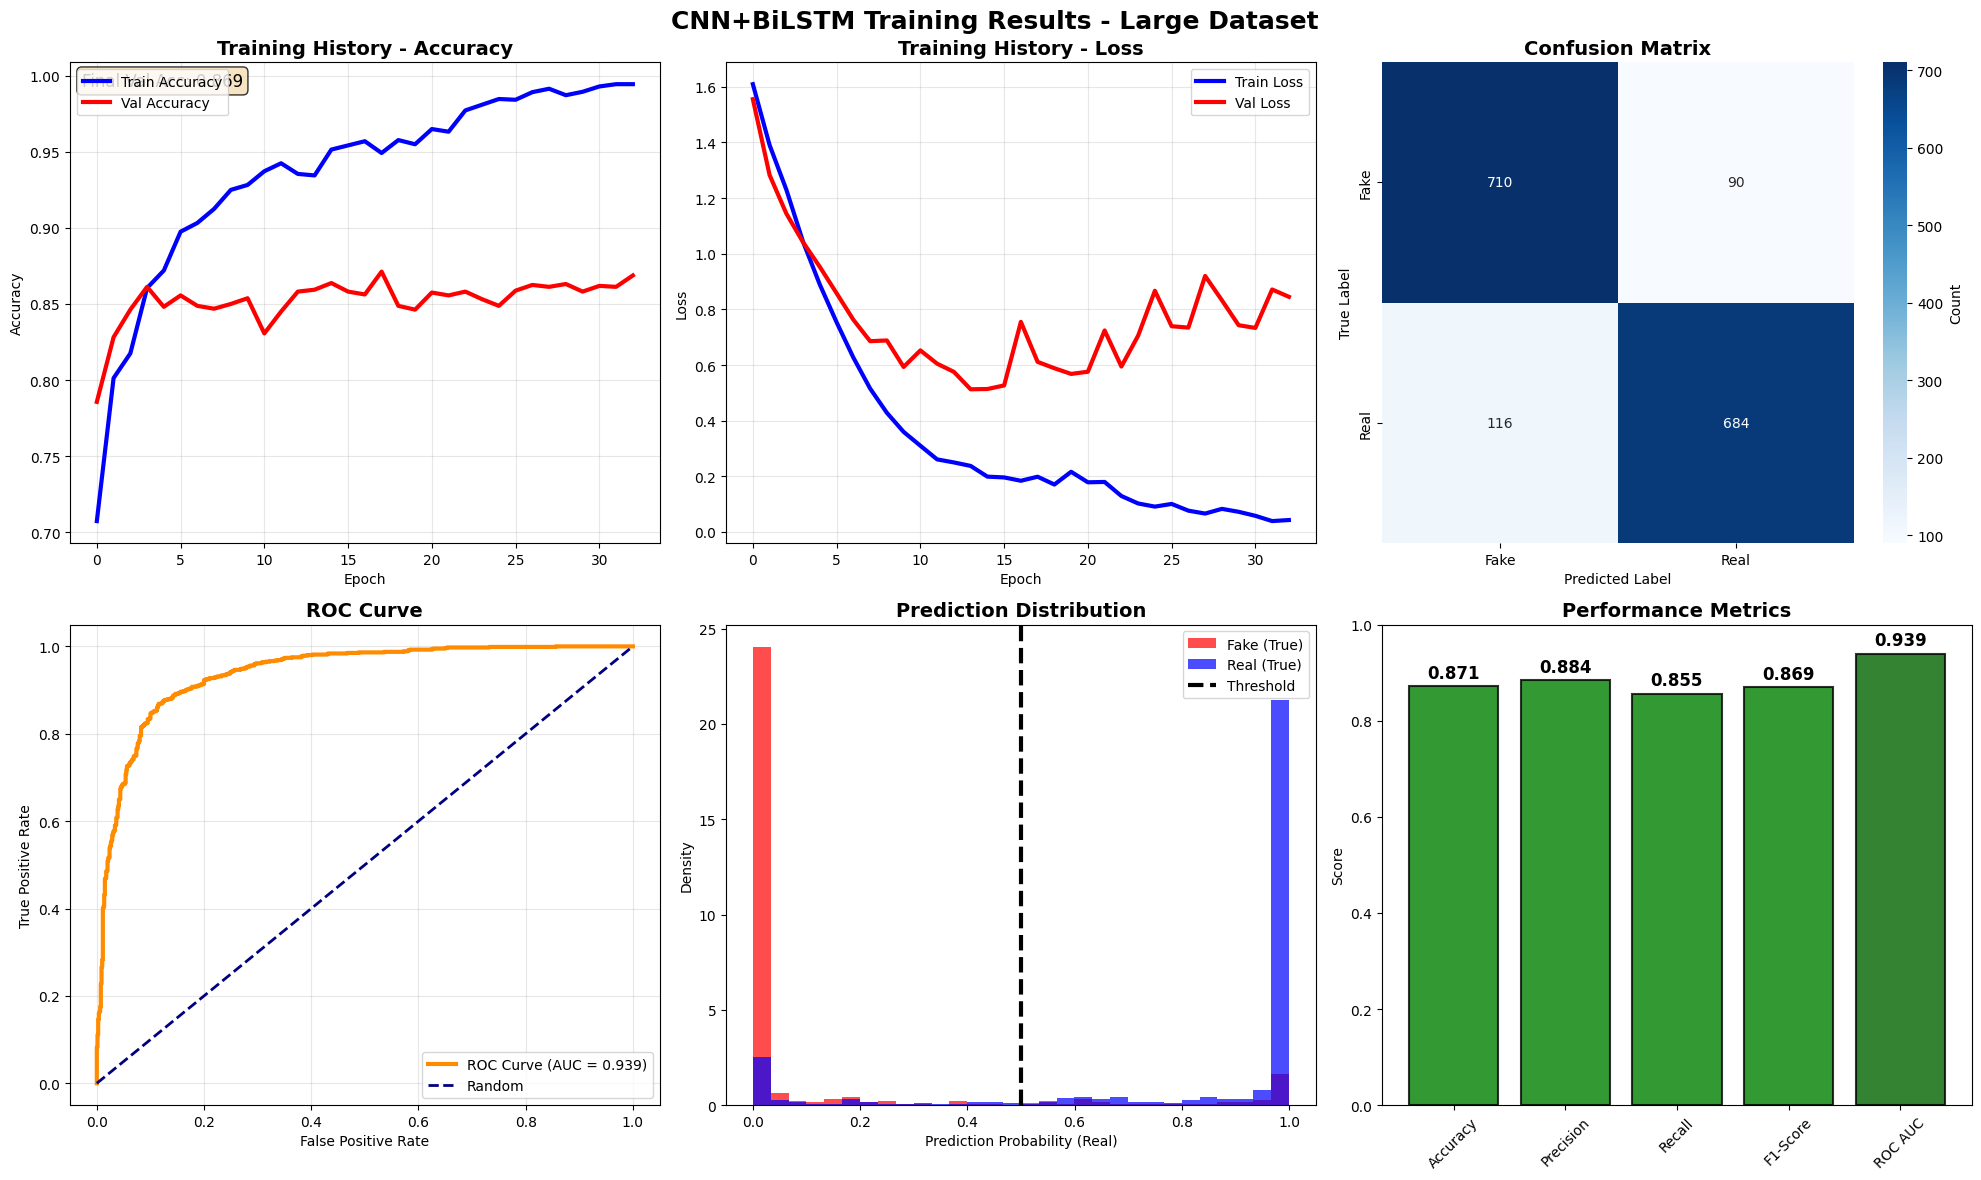


Detailed Classification Report:
              precision    recall  f1-score   support

        Fake       0.86      0.89      0.87       800
        Real       0.88      0.85      0.87       800

    accuracy                           0.87      1600
   macro avg       0.87      0.87      0.87      1600
weighted avg       0.87      0.87      0.87      1600


Sample Predictions Analysis (first 25 test samples):
 #   True   Pred   Conf   Status
-----------------------------------------------------------------
 1   Fake   Fake  1.000 ✓ CORRECT
 2   Fake   Real  0.946  ✗ WRONG
 3   Fake   Fake  1.000 ✓ CORRECT
 4   Fake   Fake  1.000 ✓ CORRECT
 5   Fake   Fake  0.999 ✓ CORRECT
 6   Fake   Fake  0.983 ✓ CORRECT
 7   Fake   Fake  1.000 ✓ CORRECT
 8   Fake   Fake  1.000 ✓ CORRECT
 9   Fake   Fake  1.000 ✓ CORRECT
10   Fake   Fake  1.000 ✓ CORRECT
11   Fake   Fake  0.999 ✓ CORRECT
12   Fake   Fake  1.000 ✓ CORRECT
13   Fake   Fake  0.999 ✓ CORRECT
14   Fake   Fake  0.999 ✓ CORRECT
15   Fake   

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.regularizers import l2
import warnings
warnings.filterwarnings('ignore')

class FixedCNNBiLSTMTrainer:
    """Fixed CNN+BiLSTM trainer using cached features"""
    
    def __init__(self):
        self.model = None
        self.history = None
        
        # Create output directories
        os.makedirs('models', exist_ok=True)
        os.makedirs('plots', exist_ok=True)
        
        print("Fixed CNN+BiLSTM Trainer - Using Cached Features")
        print("=" * 50)
    
    def build_fixed_cnn_bilstm_model(self, input_shape):
        """Build CNN + BiLSTM model with FIXED variable names"""
        
        print(f"Building CNN+BiLSTM model with input shape: {input_shape}")
        
        inputs = layers.Input(shape=input_shape)
        
        # Multi-scale 1D convolutions for feature refinement
        conv1 = layers.Conv1D(128, 3, activation='relu', padding='same')(inputs)
        conv1 = layers.BatchNormalization()(conv1)
        conv1 = layers.Dropout(0.2)(conv1)
        
        conv2 = layers.Conv1D(128, 5, activation='relu', padding='same')(inputs)
        conv2 = layers.BatchNormalization()(conv2)
        conv2 = layers.Dropout(0.2)(conv2)
        
        # Concatenate multi-scale features
        conv_concat = layers.concatenate([conv1, conv2])
        
        # Bidirectional LSTM layers
        lstm1 = layers.Bidirectional(
            layers.LSTM(256, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)
        )(conv_concat)
        lstm1 = layers.LayerNormalization()(lstm1)
        
        lstm2 = layers.Bidirectional(
            layers.LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)
        )(lstm1)
        lstm2 = layers.LayerNormalization()(lstm2)
        
        # Attention mechanism
        attention_weights = layers.Dense(1, activation='tanh')(lstm2)
        attention_weights = layers.Flatten()(attention_weights)
        attention_weights = layers.Activation('softmax')(attention_weights)
        attention_weights = layers.RepeatVector(256)(attention_weights)
        attention_weights = layers.Permute([2, 1])(attention_weights)
        
        # Apply attention
        attended_features = layers.Multiply()([lstm2, attention_weights])
        attended_features = layers.Lambda(
            lambda x: tf.reduce_sum(x, axis=1),
            output_shape=(256,)
        )(attended_features)
        
        # Global pooling features
        global_max = layers.GlobalMaxPooling1D()(lstm2)
        global_avg = layers.GlobalAveragePooling1D()(lstm2)
        
        # Combine features
        combined = layers.concatenate([attended_features, global_max, global_avg])
        
        # Classification head - FIXED VARIABLE NAMES
        dense1 = layers.Dense(512, activation='relu', kernel_regularizer=l2(0.001))(combined)
        dense1_bn = layers.BatchNormalization()(dense1)
        dropout1 = layers.Dropout(0.5)(dense1_bn)
        
        dense2 = layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001))(dropout1)
        dense2_bn = layers.BatchNormalization()(dense2)
        dropout2 = layers.Dropout(0.4)(dense2_bn)  # FIXED: was dropout2 = Dropout(dropout2)
        
        dense3 = layers.Dense(128, activation='relu')(dropout2)
        dropout3 = layers.Dropout(0.3)(dense3)
        
        outputs = layers.Dense(1, activation='sigmoid')(dropout3)
        
        model = models.Model(inputs, outputs)
        
        # Compile model
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy', 'precision', 'recall']
        )
        
        return model
    
    def load_cached_features(self):
        """Load the cached features from /kaggle/working"""
        
        print("Loading cached features from /kaggle/working...")
        
        # Try different possible cached file names
        possible_paths = [
            # Large training features (what you just created)
            ('/kaggle/working/features/train_features_large_2000.npy', '/kaggle/working/features/test_features_large_800.npy',
             '/kaggle/working/features/train_labels_large_2000.npy', '/kaggle/working/features/test_labels_large_800.npy'),
            
            # Alternative naming
            ('/kaggle/working/features/train_features_2000.npy', '/kaggle/working/features/test_features_800.npy',
             '/kaggle/working/features/train_labels_2000.npy', '/kaggle/working/features/test_labels_800.npy'),
            
            # Check for any features files
            ('/kaggle/working/features/X_train_features.npy', '/kaggle/working/features/X_test_features.npy',
             '/kaggle/working/features/y_train_labels.npy', '/kaggle/working/features/y_test_labels.npy'),
        ]
        
        # Try to find existing cached features
        for train_feat_path, test_feat_path, train_label_path, test_label_path in possible_paths:
            if all(os.path.exists(p) for p in [train_feat_path, test_feat_path, train_label_path, test_label_path]):
                print(f"Found cached features at: {train_feat_path}")
                
                X_train = np.load(train_feat_path)
                X_test = np.load(test_feat_path)
                y_train = np.load(train_label_path)
                y_test = np.load(test_label_path)
                
                print(f"Loaded successfully:")
                print(f"  X_train: {X_train.shape}")
                print(f"  X_test:  {X_test.shape}")
                print(f"  y_train: {y_train.shape} (fake={np.sum(y_train==0)}, real={np.sum(y_train==1)})")
                print(f"  y_test:  {y_test.shape} (fake={np.sum(y_test==0)}, real={np.sum(y_test==1)})")
                
                return X_train, X_test, y_train, y_test
        
        # If no cached features found, list available files
        features_dir = '/kaggle/working/features'
        if os.path.exists(features_dir):
            print(f"Available files in {features_dir}:")
            for file in os.listdir(features_dir):
                if file.endswith('.npy'):
                    file_path = os.path.join(features_dir, file)
                    try:
                        arr = np.load(file_path)
                        print(f"  {file}: {arr.shape}")
                    except:
                        print(f"  {file}: Error loading")
        
        raise FileNotFoundError("No cached features found! Please check the file paths.")
    
    def train_with_cached_features(self, epochs=50):
        """Train model using cached features"""
        
        print("TRAINING WITH CACHED FEATURES")
        print("=" * 40)
        
        # Load cached features
        X_train, X_test, y_train, y_test = self.load_cached_features()
        
        # Build model
        input_shape = (X_train.shape[1], X_train.shape[2])
        self.model = self.build_fixed_cnn_bilstm_model(input_shape)
        
        print("\nModel Summary:")
        self.model.summary()
        
        # Calculate class weights
        class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}
        print(f"\nClass weights: {class_weight_dict}")
        
        # Callbacks
        callbacks_list = [
            callbacks.EarlyStopping(
                monitor='val_accuracy', 
                patience=15, 
                restore_best_weights=True, 
                verbose=1
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', 
                factor=0.5, 
                patience=8, 
                min_lr=1e-7, 
                verbose=1
            ),
            callbacks.ModelCheckpoint(
                '/kaggle/working/models/best_cnn_bilstm_fixed_model.h5',
                monitor='val_accuracy', 
                save_best_only=True, 
                verbose=1
            ),
            callbacks.CSVLogger('/kaggle/working/models/training_history_fixed.csv')
        ]
        
        # Train model
        print(f"\nStarting training for {epochs} epochs...")
        print("=" * 50)
        
        self.history = self.model.fit(
            X_train, y_train,
            validation_data=(X_test, y_test),
            epochs=epochs,
            batch_size=16,
            class_weight=class_weight_dict,
            callbacks=callbacks_list,
            verbose=1
        )
        
        # Final evaluation
        print("\n" + "=" * 50)
        print("FINAL MODEL EVALUATION")
        print("=" * 50)
        
        test_loss, test_acc, test_prec, test_rec = self.model.evaluate(X_test, y_test, verbose=0)
        print(f"Test Accuracy:  {test_acc:.4f} ({test_acc*100:.1f}%)")
        print(f"Test Precision: {test_prec:.4f}")
        print(f"Test Recall:    {test_rec:.4f}")
        
        # Create comprehensive evaluation
        results = self.evaluate_and_plot_results(X_test, y_test)
        
        return self.history, results
    
    def evaluate_and_plot_results(self, X_test, y_test):
        """Comprehensive evaluation with plots"""
        
        print("\nCreating comprehensive evaluation plots...")
        
        # Predictions
        y_pred_proba = self.model.predict(X_test, verbose=0)
        y_pred = (y_pred_proba > 0.5).astype(int).flatten()
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        print(f"\nDetailed Metrics:")
        print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.1f}%)")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  F1-Score:  {f1:.4f}")
        
        # Create comprehensive plots
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        fig.suptitle('CNN+BiLSTM Training Results - Large Dataset', fontsize=18, fontweight='bold')
        
        # 1. Training History - Accuracy
        if self.history:
            axes[0,0].plot(self.history.history['accuracy'], label='Train Accuracy', linewidth=3, color='blue')
            axes[0,0].plot(self.history.history['val_accuracy'], label='Val Accuracy', linewidth=3, color='red')
            axes[0,0].set_title('Training History - Accuracy', fontsize=14, fontweight='bold')
            axes[0,0].set_xlabel('Epoch')
            axes[0,0].set_ylabel('Accuracy')
            axes[0,0].legend()
            axes[0,0].grid(True, alpha=0.3)
            
            # Add final accuracy text
            final_acc = self.history.history['val_accuracy'][-1]
            axes[0,0].text(0.02, 0.98, f'Final Val Acc: {final_acc:.3f}', 
                          transform=axes[0,0].transAxes, fontsize=12, 
                          verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        # 2. Training History - Loss
        if self.history:
            axes[0,1].plot(self.history.history['loss'], label='Train Loss', linewidth=3, color='blue')
            axes[0,1].plot(self.history.history['val_loss'], label='Val Loss', linewidth=3, color='red')
            axes[0,1].set_title('Training History - Loss', fontsize=14, fontweight='bold')
            axes[0,1].set_xlabel('Epoch')
            axes[0,1].set_ylabel('Loss')
            axes[0,1].legend()
            axes[0,1].grid(True, alpha=0.3)
        
        # 3. Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,2],
                   xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'],
                   cbar_kws={'label': 'Count'})
        axes[0,2].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
        axes[0,2].set_ylabel('True Label')
        axes[0,2].set_xlabel('Predicted Label')
        
        # 4. ROC Curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        axes[1,0].plot(fpr, tpr, color='darkorange', lw=3, 
                      label=f'ROC Curve (AUC = {roc_auc:.3f})')
        axes[1,0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
        axes[1,0].set_xlabel('False Positive Rate')
        axes[1,0].set_ylabel('True Positive Rate')
        axes[1,0].set_title('ROC Curve', fontsize=14, fontweight='bold')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)
        
        # 5. Prediction Distribution
        fake_probs = y_pred_proba[y_test == 0].flatten()
        real_probs = y_pred_proba[y_test == 1].flatten()
        
        axes[1,1].hist(fake_probs, bins=30, alpha=0.7, label='Fake (True)', color='red', density=True)
        axes[1,1].hist(real_probs, bins=30, alpha=0.7, label='Real (True)', color='blue', density=True)
        axes[1,1].axvline(x=0.5, color='black', linestyle='--', label='Threshold', linewidth=3)
        axes[1,1].set_xlabel('Prediction Probability (Real)')
        axes[1,1].set_ylabel('Density')
        axes[1,1].set_title('Prediction Distribution', fontsize=14, fontweight='bold')
        axes[1,1].legend()
        
        # 6. Metrics Bar Chart
        metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']
        values = [accuracy, precision, recall, f1, roc_auc]
        
        colors = ['darkgreen' if v >= 0.9 else 'green' if v >= 0.8 else 'orange' if v >= 0.6 else 'red' for v in values]
        bars = axes[1,2].bar(metrics, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
        axes[1,2].set_ylim(0, 1)
        axes[1,2].set_ylabel('Score')
        axes[1,2].set_title('Performance Metrics', fontsize=14, fontweight='bold')
        axes[1,2].tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for bar, value in zip(bars, values):
            axes[1,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                          f'{value:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('/kaggle/working/plots/cnn_bilstm_final_results.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Detailed Classification Report
        print(f"\nDetailed Classification Report:")
        print("=" * 50)
        print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))
        
        # Sample predictions analysis
        print(f"\nSample Predictions Analysis (first 25 test samples):")
        print("=" * 65)
        print(f"{'#':>2} {'True':>6} {'Pred':>6} {'Conf':>6} {'Status':>8}")
        print("-" * 65)
        
        correct_count = 0
        for i in range(min(25, len(y_test))):
            true_label = 'Fake' if y_test[i] == 0 else 'Real'
            pred_label = 'Fake' if y_pred[i] == 0 else 'Real'
            confidence = y_pred_proba[i][0] if y_pred[i] == 1 else 1 - y_pred_proba[i][0]
            
            is_correct = y_test[i] == y_pred[i]
            if is_correct:
                correct_count += 1
                
            status = "✓ CORRECT" if is_correct else "✗ WRONG"
            print(f"{i+1:>2} {true_label:>6} {pred_label:>6} {confidence:>6.3f} {status:>8}")
        
        sample_accuracy = correct_count / min(25, len(y_test))
        print("-" * 65)
        print(f"Sample Accuracy: {correct_count}/{min(25, len(y_test))} = {sample_accuracy:.1%}")
        
        return {
            'accuracy': accuracy,
            'precision': precision, 
            'recall': recall,
            'f1_score': f1,
            'roc_auc': roc_auc,
            'confusion_matrix': cm,
            'sample_accuracy': sample_accuracy
        }

# Main execution function
def run_fixed_training(epochs=50):
    """Run the fixed training with cached features"""
    
    print("=" * 70)
    print("🚀 STARTING FIXED CNN+BiLSTM TRAINING WITH CACHED FEATURES")
    print("=" * 70)
    
    trainer = FixedCNNBiLSTMTrainer()
    
    try:
        history, results = trainer.train_with_cached_features(epochs=epochs)
        
        print("\n" + "=" * 70)
        print("✅ TRAINING COMPLETED SUCCESSFULLY!")
        print("=" * 70)
        
        print("📊 Final Results Summary:")
        print(f"   • Accuracy:  {results['accuracy']:.1%}")
        print(f"   • Precision: {results['precision']:.3f}")
        print(f"   • Recall:    {results['recall']:.3f}")
        print(f"   • F1-Score:  {results['f1_score']:.3f}")
        print(f"   • ROC AUC:   {results['roc_auc']:.3f}")
        
        print("\n📁 Files saved:")
        print("   • /kaggle/working/models/best_cnn_bilstm_fixed_model.h5")
        print("   • /kaggle/working/models/training_history_fixed.csv")
        print("   • /kaggle/working/plots/cnn_bilstm_final_results.png")
        
        return trainer, history, results
        
    except Exception as e:
        print(f"❌ Error during training: {e}")
        return None, None, None


trainer, history, results = run_fixed_training(epochs=50)